In [1]:
# Basic and plotting packages
suppressMessages( library(kableExtra) )
suppressMessages( library(ggplot2) )
suppressMessages( library(plotly) )
suppressMessages( library(cowplot) )
suppressMessages( library(latex2exp) )
t = theme(plot.title = element_text(size=26, hjust=0.5),
          axis.title = element_text(size=20),
          axis.text = element_text(size=16),
          legend.title = element_text(size = 20),
          legend.text = element_text(size = 16),
          plot.subtitle = element_text(size = 18, face="bold"))
theme_set(theme_minimal()+t)
options(repr.plot.width=16, repr.plot.height=6)

suppressMessages( library(gtools) )

# Utils packages
suppressMessages( library(dplyr) ) # Pipeline
suppressMessages( library(snow) ) # Parallel apply, sapply, lapply
suppressMessages( library(pbapply) ) # Progressbar apply, sapply, lapply
suppressMessages( library(pbmcapply) ) # Progress bar in for loop (needs to be installed manually: https://cran.r-project.org/web/packages/pbmcapply/index.html)

suppressMessages( library(TSA) )
suppressMessages( library(rugarch) )

suppressMessages( library(mvtnorm) )
suppressMessages( library(tmvmixnorm) )
suppressMessages( library(truncnorm) )

suppressMessages( library(extRemes) )

suppressMessages( library(VGAM) )

library(progress)

# Integrate R with C++
suppressMessages( library(Rcpp) )
# Compile the c++ codes
Sys.setenv(PKG_LIBS = "-lmpfr -lgmp -lquadmath")
sourceCpp("../divergence_parallel.cpp")
Sys.setenv(PKG_LIBS = "-lmpfr -lgmp -lquadmath", PKG_CXXFLAGS="-O3 -ffast-math")
sourceCpp("posterior_sampler_eigen.cpp")

In [2]:
# Sampler for the GARCH(p,q) model
sample_garch <- function(T, alpha, beta) {
  # Extract the intercept (alpha0) and calculate p (ARCH lags)
  alpha0 <- alpha[1]
  p <- length(alpha) - 1
  q <- length(beta)
  
  # Initialize vectors to store the series and variances
  y <- numeric(T)
  h <- numeric(T)
  
  # Initialize the first observation
  h[1] <- alpha0
  y[1] <- rnorm(1, mean = 0, sd = sqrt(h[1]))
  
  # Loop through the remaining time steps
  for (t in 2:T) {
    # Start with the unconditional variance constant
    h_t <- alpha0
    
    # Add ARCH terms (alpha * y_{t-i}^2)
    if (p > 0) {
      for (i in 1:p) {
        if (t - i > 0) {
          # Shift index by +1 because alpha[1] is the intercept
          h_t <- h_t + alpha[i + 1] * (y[t - i]^2)
        }
      }
    }
    
    # Add GARCH terms (beta * h_{t-j})
    if (q > 0) {
      for (j in 1:q) {
        if (t - j > 0) {
          h_t <- h_t + beta[j] * h[t - j]
        }
      }
    }
    
    # Store the variance and generate the new observation
    h[t] <- h_t
    y[t] <- rnorm(1, mean = 0, sd = sqrt(h[t]))
  }
  
  return(list(y = y, h = h))
}

In [3]:
fit_garch11_dirichlet <- function(y, alpha0 = c(1.0, 0.3), beta0 = c(0.3), niter = 10000, burnin = 5000, tau = 500, sigma_alpha0 = 0.05){
    # -------------------------------- Fit the Bayesian model --------------------------------
    fit_obj <- sample_posterior_garch_dirichlet_cpp(y, niter, c(1.0, 0.3), c(0.3), tau, sigma_alpha0)
    
    # -------------------------------- Process posterior sample --------------------------------
    final_alpha <- fit_obj$alpha[ (burnin+1):niter, ]
    final_beta <- fit_obj$beta[ (burnin+1):niter, ]
    final_hs <- fit_obj$h[(burnin+1):niter,]
    
    summ_colnames <- c("mean", "median", "sd", "2.5%", "25%", "50%", "75%", "97.5%")
    summ_rownames <- c("alpha0", "alpha1", "beta")
    summ <- data.frame(
        c(mean(final_alpha[,1]), mean(final_alpha[,2]), mean(final_beta)),
        c(median(final_alpha[,1]), median(final_alpha[,2]), median(final_beta)),
        c(sd(final_alpha[,1]), sd(final_alpha[,2]), sd(final_beta)),
        c(quantile(final_alpha[,1], 0.025), quantile(final_alpha[,2], 0.025), quantile(final_beta, 0.025)),
        c(quantile(final_alpha[,1], 0.25), quantile(final_alpha[,2], 0.25), quantile(final_beta, 0.25)),
        c(quantile(final_alpha[,1], 0.5), quantile(final_alpha[,2], 0.5), quantile(final_beta, 0.5)),
        c(quantile(final_alpha[,1], 0.75), quantile(final_alpha[,2], 0.75), quantile(final_beta, 0.75)),
        c(quantile(final_alpha[,1], 0.975), quantile(final_alpha[,2], 0.975), quantile(final_beta, 0.975))
    )
    colnames(summ) <- summ_colnames
    rownames(summ) <- summ_rownames

    return(list(
        "alpha" = final_alpha,
        "beta" = final_beta,
        "y" = y,
        "h" = final_hs,
        "fit_obj" = fit_obj,
        "summary" = summ
    ))
}

In [4]:
plot_divergences <- function(fit, div_perturbed, q = 0.95){    
    q_y_KL <- quantile_hat(fit$alpha[,2], fit$beta, divergence_models$KL, q) %>% median
    q_y_KL_rev <- quantile_hat(fit$alpha[,2], fit$beta, divergence_models$KL_rev, q) %>% median
    q_y_J <- quantile_hat(fit$alpha[,2], fit$beta, divergence_models$J, q) %>% median
    q_y_L1 <- quantile_hat(fit$alpha[,2], fit$beta, divergence_models$L1, q) %>% median
    q_y_chi2 <- exp(quantile_hat(fit$alpha[,2], fit$beta, divergence_models$chi2, q)) %>% median
    q_y_chi2_rev <- exp(quantile_hat(fit$alpha[,2], fit$beta, divergence_models$chi2_rev, q)) %>% median

    g_KL <- ggplot()+
        geom_line(aes(x = as.numeric(rownames(div_perturbed)), y = div_perturbed$KL))+
        geom_hline(aes(yintercept = q_y_KL), linetype = "dashed")+
        geom_text(aes(x = as.numeric(rownames(div_perturbed)), y = div_perturbed$KL+0.02), label = ifelse(div_perturbed$KL > q_y_KL, rownames(div_perturbed), ""), size = 7)+
        labs(x = "Indices", y = "KL")
    g_KL_rev <- ggplot()+
        geom_line(aes(x = as.numeric(rownames(div_perturbed)), y = div_perturbed$KL_rev))+
        geom_hline(aes(yintercept = q_y_KL_rev), linetype = "dashed")+
        geom_text(aes(x = as.numeric(rownames(div_perturbed)), y = div_perturbed$KL_rev+0.02), label = ifelse(div_perturbed$KL_rev > q_y_KL_rev, rownames(div_perturbed), ""), size = 7)+
        labs(x = "Indices", y = "KL reverse")
    g_J <- ggplot()+
        geom_line(aes(x = as.numeric(rownames(div_perturbed)), y = div_perturbed$J))+
        geom_text(aes(x = as.numeric(rownames(div_perturbed)), y = div_perturbed$J+0.02), label = ifelse(div_perturbed$J > q_y_J, rownames(div_perturbed), ""), size = 7)+
        geom_hline(aes(yintercept = q_y_J), linetype = "dashed")+
        labs(x = "Indices", y = "J")
    g_L1 <- ggplot()+
        geom_line(aes(x = as.numeric(rownames(div_perturbed)), y = div_perturbed$L1))+
        geom_text(aes(x = as.numeric(rownames(div_perturbed)), y = div_perturbed$L1+0.02), label = ifelse(div_perturbed$L1 > q_y_L1, rownames(div_perturbed), ""), size = 7)+
        geom_hline(aes(yintercept = q_y_L1), linetype = "dashed")+
        labs(x = "Indices", y = TeX("$L_1$") )
    g_chi2 <- ggplot()+
        geom_line(aes(x = as.numeric(rownames(div_perturbed)), y = div_perturbed$chi2 ))+
        geom_text(aes(x = as.numeric(rownames(div_perturbed)), y = div_perturbed$chi2+0.02), label = ifelse(div_perturbed$chi2 > q_y_chi2, rownames(div_perturbed), ""), size = 7)+
        geom_hline(aes(yintercept = q_y_chi2), linetype = "dashed")+
        labs(x = "Indices", y = TeX("$\\chi^2$"))
    g_chi2_rev <- ggplot()+
        geom_line(aes(x = as.numeric(rownames(div_perturbed)), y = div_perturbed$chi2_rev ))+
        geom_text(aes(x = as.numeric(rownames(div_perturbed)), y = div_perturbed$chi2_rev+0.02), label = ifelse(div_perturbed$chi2_rev > q_y_chi2_rev, rownames(div_perturbed), ""), size = 7)+
        geom_hline(aes(yintercept = q_y_chi2_rev), linetype = "dashed")+
        labs(x = "Indices", y = TeX("$\\chi^2$ reverse"))
    
    plot_grid(g_KL, g_KL_rev, g_J, g_L1, g_chi2, g_chi2_rev, nrow = 2)
}

In [5]:
files <- paste0("Simulations2/", c("sim1.1.RData", "sim1.2.RData", "sim1.3.RData", "sim1.4.RData", "sim1.5.RData",
                                   "sim1.6.RData", "sim1.7.RData", "sim1.8.RData", "sim1.9.RData", "sim1.10.RData",
                                   "sim2.1.RData", "sim2.2.RData", "sim2.3.RData", "sim2.4.RData", "sim2.5.RData",
                                   "sim2.6.RData", "sim2.7.RData", "sim2.8.RData", "sim2.9.RData", "sim2.10.RData",
                                   "sim3.1.RData", "sim3.2.RData", "sim3.3.RData", "sim3.4.RData", "sim3.5.RData",
                                   "sim3.6.RData", "sim3.7.RData", "sim3.8.RData", "sim3.9.RData", "sim3.10.RData"))
for(file in files){
    load(file)
}

# Given a table of divergence metrics, take the maximum for each column
get_max_div <- function(div_table){
    apply(div_table, 2, max)
}

# Given a list of divergence tables, take the maximum in each column and join them in the same table
list_max_div <- function(div_tables){
    max_table <- sapply(div_tables, function(div_table){
        get_max_div(div_table)
    })
    col_names <- rownames(max_table)
    max_table <- t(max_table)
    colnames(max_table) <- col_names
    max_table
}

In [6]:
max_div1.1 <- list_max_div(sim1.1_1000$divergences)
max_div1.2 <- list_max_div(sim1.2_1000$divergences)
max_div1.3 <- list_max_div(sim1.3_1000$divergences)
max_div1.4 <- list_max_div(sim1.4_1000$divergences)
max_div1.5 <- list_max_div(sim1.5_1000$divergences)
max_div1.6 <- list_max_div(sim1.6_1000$divergences)
max_div1.7 <- list_max_div(sim1.7_1000$divergences)
max_div1.8 <- list_max_div(sim1.8_1000$divergences)
max_div1.9 <- list_max_div(sim1.9_1000$divergences)
max_div1.10 <- list_max_div(sim1.10_1000$divergences)

max_div2.1 <- list_max_div(sim2.1_1000$divergences)
max_div2.2 <- list_max_div(sim2.2_1000$divergences)
max_div2.3 <- list_max_div(sim2.3_1000$divergences)
max_div2.4 <- list_max_div(sim2.4_1000$divergences)
max_div2.5 <- list_max_div(sim2.5_1000$divergences)
max_div2.6 <- list_max_div(sim2.6_1000$divergences)
max_div2.7 <- list_max_div(sim2.7_1000$divergences)
max_div2.8 <- list_max_div(sim2.8_1000$divergences)
max_div2.9 <- list_max_div(sim2.9_1000$divergences)
max_div2.10 <- list_max_div(sim2.10_1000$divergences)

max_div3.1 <- list_max_div(sim3.1_1000$divergences)
max_div3.2 <- list_max_div(sim3.2_1000$divergences)
max_div3.3 <- list_max_div(sim3.3_1000$divergences)
max_div3.4 <- list_max_div(sim3.4_1000$divergences)
max_div3.5 <- list_max_div(sim3.5_1000$divergences)
max_div3.6 <- list_max_div(sim3.6_1000$divergences)
max_div3.7 <- list_max_div(sim3.7_1000$divergences)
max_div3.8 <- list_max_div(sim3.8_1000$divergences)
max_div3.9 <- list_max_div(sim3.9_1000$divergences)
max_div3.10 <- list_max_div(sim3.10_1000$divergences)

scenarios <- as.list(c(rep("1", 10), rep("2", 10), rep("3", 10)))
sims <- list(sim1.1_1000, sim1.2_1000, sim1.3_1000, sim1.4_1000, sim1.5_1000, sim1.6_1000, sim1.7_1000, sim1.8_1000, sim1.9_1000, sim1.10_1000,
             sim2.1_1000, sim2.2_1000, sim2.3_1000, sim2.4_1000, sim2.5_1000, sim2.6_1000, sim2.7_1000, sim2.8_1000, sim2.9_1000, sim2.10_1000,
             sim3.1_1000, sim3.2_1000, sim3.3_1000, sim3.4_1000, sim3.5_1000, sim3.6_1000, sim3.7_1000, sim3.8_1000, sim3.9_1000, sim3.10_1000)
max_divs <- list(max_div1.1, max_div1.2, max_div1.3, max_div1.4, max_div1.5, max_div1.6, max_div1.7, max_div1.8, max_div1.9, max_div1.10,
                 max_div2.1, max_div2.2, max_div2.3, max_div2.4, max_div2.5, max_div2.6, max_div2.7, max_div2.8, max_div2.9, max_div2.10,
                 max_div3.1, max_div3.2, max_div3.3, max_div3.4, max_div3.5, max_div3.6, max_div3.7, max_div3.8, max_div3.9, max_div3.10)

extract_quantile_regression_data <- function(max_divs, sims){
    df <- data.frame()
    for(i in 1:length(max_divs)){
        name_index <- ifelse(i %% 10 == 0, i/10, floor(i/10)+1)
        name_scenario <- paste0(scenarios[[i]], ".", ifelse(i %% 10 == 0, 10, i %% 10) )
        pars <- data.frame(
            "index" = rep(name_index, nrow(max_divs[[i]])),
            "scenario" = rep(name_scenario, nrow(max_divs[[i]])),
            "alpha0" = rep(sims[[i]]$pars[1], nrow(max_divs[[i]])),
            "alpha1" = rep(sims[[i]]$pars[2], nrow(max_divs[[i]])),
            "beta" = rep(sims[[i]]$pars[3], nrow(max_divs[[i]]))
        )
        rows <- max_divs[[i]]
        rows <- cbind(pars, rows)
        df <- rbind(df, rows)
    }
    df
}

df_quantile_regression <- extract_quantile_regression_data(max_divs, sims)
head(df_quantile_regression, 3)
tail(df_quantile_regression, 3)

,index,scenario,alpha0,alpha1,beta,KL,KL_rev,J,chi2,chi2_rev,chi2_sym,L1,H,JS
,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,1.1,0.1,0.1,0.85,0.07350142,0.07757285,0.1510743,0.1802525,0.1509891,0.3312415,0.1511813,0.01867488,0.01847585
2,1,1.1,0.1,0.1,0.85,0.10350986,0.10565142,0.2091613,0.2366189,0.2222664,0.4588853,0.1818924,0.02584610,0.02555801
3,1,1.1,0.1,0.1,0.85,0.09071425,0.08928334,0.1799976,0.1923452,0.2029481,0.3952933,0.1677423,0.02224278,0.02199710


,index,scenario,alpha0,alpha1,beta,KL,KL_rev,J,chi2,chi2_rev,chi2_sym,L1,H,JS
,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
7498,3,3.10,2,0.85,0.1,2.7806838,2.4120150,5.1926988,56.615432,4821.3856675,4878.001099,0.7272279,0.46420588,0.38437488
7499,3,3.10,2,0.85,0.1,0.2117969,0.1917605,0.4035573,0.414132,0.5954217,1.009554,0.2506540,0.04914824,0.04798806
7500,3,3.10,2,0.85,0.1,0.7744249,0.5570947,1.3315195,1.449077,10.6189251,12.068002,0.4228753,0.14880613,0.13738578


In [7]:
divergence_metrics <- c("KL", "KL_rev", "J", "L1", "H", "JS", "chi2", "chi2_rev")

divergence_models <- list()
for(metric in divergence_metrics){   
    if(metric == "chi2" | metric == "chi2_rev"){
        form <- as.formula(paste0("log(", metric, ")", " ~ alpha1 + beta"))
        gev_pars_fit_model <- vglm(form,
                                  family = gumbel(llocation = "identitylink", lscale = "loglink", zero = NULL),
                                  data = df_quantile_regression, 
                                  maxit = 100)
    }else{
        form <- as.formula(paste0(metric, " ~ alpha1 + beta"))
        gev_pars_fit_model <- vglm(form,
                                   family = gev(llocation = "identitylink", lscale = "loglink", lshape = "identitylink", zero = NULL),
                                   data = df_quantile_regression, maxit = 100)
    }
    print(form)
    divergence_models[[metric]] <- gev_pars_fit_model
}

KL ~ alpha1 + beta
KL_rev ~ alpha1 + beta
J ~ alpha1 + beta
L1 ~ alpha1 + beta
H ~ alpha1 + beta
JS ~ alpha1 + beta
log(chi2) ~ alpha1 + beta
log(chi2_rev) ~ alpha1 + beta


In [8]:
location_hat <- function(alpha1, beta, fit){
    # Extract coefficient matrix
    c_mat <- coef(fit, matrix = TRUE)
    # Column 1 is always the location parameter
    c_mat["(Intercept)", 1] + c_mat["alpha1", 1] * alpha1 + c_mat["beta", 1] * beta
}

scale_hat <- function(alpha1, beta, fit){
    c_mat <- coef(fit, matrix = TRUE)
    # Column 2 is always the log(scale) parameter
    exp( c_mat["(Intercept)", 2] + c_mat["alpha1", 2] * alpha1 + c_mat["beta", 2] * beta )
}

shape_hat <- function(alpha1, beta, fit){
    c_mat <- coef(fit, matrix = TRUE)    
    # Check if the model has a 3rd column (Shape parameter)
    if (ncol(c_mat) < 3) {
        # If it is a Gumbel model, the shape parameter is strictly 0
        return(0)
    } else {
        # If it is a GEV model, calculate the dynamic shape
        c_mat["(Intercept)", 3] + c_mat["alpha1", 3] * alpha1 + c_mat["beta", 3] * beta
    }
}

quantile_hat <- function(alpha1, beta, fit, q){
    location <- location_hat(alpha1, beta, fit)
    scale <- scale_hat(alpha1, beta, fit)
    shape <- shape_hat(alpha1, beta, fit)
    
    # The qgev function handles shape = 0 by 
    # automatically computing the Gumbel quantile.
    VGAM::qgev(q, location = location, scale = scale, shape = shape)
}

## Metrics comparison

In [9]:
phi_KL <- function(x){
    return( -log(x) )
}

phi_KL_rev <- function(x){
    return( x*log(x) )
}

phi_J <- function(x){
    return( (x-1)*log(x) )
}

phi_L1 <- function(x){
    return( abs(x-1)/2 )
}

phi_chi2 <- function(x){
    return( (x-1)^2 )
}

phi_chi2_rev <- function(x){
    return( (x-1)^2/x )
}

In [10]:
# Calibration from Hao (2016)
p_mccullogh <- 0.8564
q_mccullogh_KL <- (phi_KL( 2*p_mccullogh ) + phi_KL( 2*(1-p_mccullogh) )) / 2
q_mccullogh_KL_rev <- (phi_KL_rev( 2*p_mccullogh ) + phi_KL_rev( 2*(1-p_mccullogh) )) / 2
q_mccullogh_J <- (phi_J( 2*p_mccullogh ) + phi_J( 2*(1-p_mccullogh) )) / 2
q_mccullogh_L1 <- (phi_L1( 2*p_mccullogh ) + phi_L1( 2*(1-p_mccullogh) )) / 2
q_mccullogh_chi2 <- (phi_chi2( 2*p_mccullogh ) + phi_chi2( 2*(1-p_mccullogh) )) / 2
q_mccullogh_chi2_rev <- (phi_chi2_rev( 2*p_mccullogh ) + phi_chi2_rev( 2*(1-p_mccullogh) )) / 2

### Scenario (a): $\alpha_1 = 0.1$, $\beta_1 = 0.3$

In [11]:
T <- 1000
niter <- 10000
burnin <- 5000

# Scenario 1: alpha1 = 0.1, beta1 = 0.3
alpha <- c(0.1, 0.1)
beta <- c(0.3)
nsim <- 100
q <- 0.95

num_detections_gevd_a <- c()
num_detections_mcculloch_a <- c()
num_detections_wang_a <- c()

set.seed(10)

pb <- txtProgressBar(min = 0, max = nsim, style = 3, width = 50, char = "=")
start <- Sys.time()
for(i in 1:nsim){
    yh <- sample_garch(T, alpha = alpha, beta = beta)
    y <- yh$y
    h <- yh$h
    
    fit_bayesian <- fit_garch11_dirichlet(y)
    thetas <- cbind(fit_bayesian$alpha[,1], fit_bayesian$alpha[,2], fit_bayesian$beta)
    hs <- fit_bayesian$h
    colnames(thetas) <- c("alpha0", "alpha1", "beta")
    
    div <- psi_divergences_cpp_parallel(thetas, hs, y, p = 1, q = 1, k_values = 1:T, verbose = FALSE)
    colnames(div) <- c("KL", "KL_rev", "J", "chi2", "chi2_rev", "chi2_sym", "L1", "H", "JS")
    div <- as.data.frame(div)

    q_y_KL <- quantile_hat(fit_bayesian$alpha[,2], fit_bayesian$beta, divergence_models$KL, q) %>% median
    q_y_KL_rev <- quantile_hat(fit_bayesian$alpha[,2], fit_bayesian$beta, divergence_models$KL_rev, q) %>% median
    q_y_J <- quantile_hat(fit_bayesian$alpha[,2], fit_bayesian$beta, divergence_models$J, q) %>% median
    q_y_L1 <- quantile_hat(fit_bayesian$alpha[,2], fit_bayesian$beta, divergence_models$L1, q) %>% median
    q_y_chi2 <- exp(quantile_hat(fit_bayesian$alpha[,2], fit_bayesian$beta, divergence_models$chi2, q)) %>% median
    q_y_chi2_rev <- exp(quantile_hat(fit_bayesian$alpha[,2], fit_bayesian$beta, divergence_models$chi2_rev, q)) %>% median

    q_wang_KL <- mean(div$KL) + 3*sd(div$KL)
    q_wang_KL_rev <- mean(div$KL_rev) + 3*sd(div$KL_rev)
    q_wang_J <- mean(div$J) + 3*sd(div$J)
    q_wang_L1 <- mean(div$L1) + 3*sd(div$L1)
    q_wang_chi2 <- mean(div$chi2) + 3*sd(div$chi2)
    q_wang_chi2_rev <- mean(div$chi2_rev) + 3*sd(div$chi2_rev)

    num_detections_gevd_a <- rbind(
        num_detections_gevd_a,
        c( sum( div$KL > q_y_KL ), sum( div$KL_rev > q_y_KL_rev ), sum( div$J > q_y_J ), sum( div$L1 > q_y_L1 ), sum( div$chi2 > q_y_chi2 ), sum( div$chi2_rev > q_y_chi2_rev ) )
    )
    num_detections_mcculloch_a <- rbind(
        num_detections_mcculloch_a,
        c( sum( div$KL > q_mccullogh_KL ), sum( div$KL_rev > q_mccullogh_KL_rev ), sum( div$J > q_mccullogh_J ), sum( div$L1 > q_mccullogh_L1 ), sum( div$chi2 > q_mccullogh_chi2 ), sum( div$chi2_rev > q_mccullogh_chi2_rev ) )
    )
    num_detections_wang_a <- rbind(
        num_detections_wang_a,
        c( sum( div$KL > q_wang_KL ), sum( div$KL_rev > q_wang_KL_rev ), sum( div$J > q_wang_J ), sum( div$L1 > q_wang_L1 ), sum( div$chi2 > q_wang_chi2 ), sum( div$chi2_rev > q_wang_chi2_rev ) )
    )

    setTxtProgressBar(pb, i)
}
elapsed <- Sys.time() - start
cat(paste0("\nElapsed time: ", elapsed))

num_detections_gevd_a <- as.data.frame( cbind( "GEVD", num_detections_gevd_a ) )
colnames(num_detections_gevd_a) <- c("cutpoint_method", "KL", "KL_rev", "J", "L1", "chi2", "chi2_rev")

num_detections_mcculloch_a <- as.data.frame( cbind( "McCullogh", num_detections_mcculloch_a ) )
colnames(num_detections_mcculloch_a) <- c("cutpoint_method", "KL", "KL_rev", "J", "L1", "chi2", "chi2_rev")

num_detections_wang_a <- as.data.frame( cbind( "Wang", num_detections_wang_a ) )
colnames(num_detections_wang_a) <- c("cutpoint_method", "KL", "KL_rev", "J", "L1", "chi2", "chi2_rev")

num_detections_a <- rbind(
    num_detections_gevd_a,
    num_detections_mcculloch_a,
    num_detections_wang_a
)

write.csv(num_detections_a, "num_detections_a.csv", row.names = FALSE)

  |==================================================| 100%
Elapsed time: 1.08140564203262

### Scenario (b): $\alpha_1 = 0.1$, $\beta_1 = 0.8$

In [12]:
T <- 1000
niter <- 10000
burnin <- 5000

# Scenario 1: alpha1 = 0.1, beta1 = 0.3
alpha <- c(0.1, 0.1)
beta <- c(0.8)
nsim <- 100
q <- 0.95

num_detections_gevd_b <- c()
num_detections_mcculloch_b <- c()
num_detections_wang_b <- c()

set.seed(10)

pb <- txtProgressBar(min = 0, max = nsim, style = 3, width = 50, char = "=")
start <- Sys.time()
for(i in 1:nsim){
    yh <- sample_garch(T, alpha = alpha, beta = beta)
    y <- yh$y
    h <- yh$h
    
    fit_bayesian <- fit_garch11_dirichlet(y)
    thetas <- cbind(fit_bayesian$alpha[,1], fit_bayesian$alpha[,2], fit_bayesian$beta)
    hs <- fit_bayesian$h
    colnames(thetas) <- c("alpha0", "alpha1", "beta")
    
    div <- psi_divergences_cpp_parallel(thetas, hs, y, p = 1, q = 1, k_values = 1:T, verbose = FALSE)
    colnames(div) <- c("KL", "KL_rev", "J", "chi2", "chi2_rev", "chi2_sym", "L1", "H", "JS")
    div <- as.data.frame(div)

    q_y_KL <- quantile_hat(fit_bayesian$alpha[,2], fit_bayesian$beta, divergence_models$KL, q) %>% median
    q_y_KL_rev <- quantile_hat(fit_bayesian$alpha[,2], fit_bayesian$beta, divergence_models$KL_rev, q) %>% median
    q_y_J <- quantile_hat(fit_bayesian$alpha[,2], fit_bayesian$beta, divergence_models$J, q) %>% median
    q_y_L1 <- quantile_hat(fit_bayesian$alpha[,2], fit_bayesian$beta, divergence_models$L1, q) %>% median
    q_y_chi2 <- exp(quantile_hat(fit_bayesian$alpha[,2], fit_bayesian$beta, divergence_models$chi2, q)) %>% median
    q_y_chi2_rev <- exp(quantile_hat(fit_bayesian$alpha[,2], fit_bayesian$beta, divergence_models$chi2_rev, q)) %>% median

    q_wang_KL <- mean(div$KL) + 3*sd(div$KL)
    q_wang_KL_rev <- mean(div$KL_rev) + 3*sd(div$KL_rev)
    q_wang_J <- mean(div$J) + 3*sd(div$J)
    q_wang_L1 <- mean(div$L1) + 3*sd(div$L1)
    q_wang_chi2 <- mean(div$chi2) + 3*sd(div$chi2)
    q_wang_chi2_rev <- mean(div$chi2_rev) + 3*sd(div$chi2_rev)

    num_detections_gevd_b <- rbind(
        num_detections_gevd_b,
        c( sum( div$KL > q_y_KL ), sum( div$KL_rev > q_y_KL_rev ), sum( div$J > q_y_J ), sum( div$L1 > q_y_L1 ), sum( div$chi2 > q_y_chi2 ), sum( div$chi2_rev > q_y_chi2_rev ) )
    )
    num_detections_mcculloch_b <- rbind(
        num_detections_mcculloch_b,
        c( sum( div$KL > q_mccullogh_KL ), sum( div$KL_rev > q_mccullogh_KL_rev ), sum( div$J > q_mccullogh_J ), sum( div$L1 > q_mccullogh_L1 ), sum( div$chi2 > q_mccullogh_chi2 ), sum( div$chi2_rev > q_mccullogh_chi2_rev ) )
    )
    num_detections_wang_b <- rbind(
        num_detections_wang_b,
        c( sum( div$KL > q_wang_KL ), sum( div$KL_rev > q_wang_KL_rev ), sum( div$J > q_wang_J ), sum( div$L1 > q_wang_L1 ), sum( div$chi2 > q_wang_chi2 ), sum( div$chi2_rev > q_wang_chi2_rev ) )
    )

    setTxtProgressBar(pb, i)
}
elapsed <- Sys.time() - start
cat(paste0("\nElapsed time: ", elapsed))

num_detections_gevd_b <- as.data.frame( cbind( "GEVD", num_detections_gevd_b ) )
colnames(num_detections_gevd_b) <- c("cutpoint_method", "KL", "KL_rev", "J", "L1", "chi2", "chi2_rev")

num_detections_mcculloch_b <- as.data.frame( cbind( "McCullogh", num_detections_mcculloch_b ) )
colnames(num_detections_mcculloch_b) <- c("cutpoint_method", "KL", "KL_rev", "J", "L1", "chi2", "chi2_rev")

num_detections_wang_b <- as.data.frame( cbind( "Wang", num_detections_wang_b ) )
colnames(num_detections_wang_b) <- c("cutpoint_method", "KL", "KL_rev", "J", "L1", "chi2", "chi2_rev")

num_detections_b <- rbind(
    num_detections_gevd_b,
    num_detections_mcculloch_b,
    num_detections_wang_b
)

write.csv(num_detections_b, "num_detections_b.csv", row.names = FALSE)

  |================================                  |  63%

### Scenario (c): $\alpha_1 = 0.5$, $\beta_1 = 0.2$

In [62]:
T <- 1000
niter <- 10000
burnin <- 5000

# Scenario 4: alpha1 = 0.5, beta1 = 0.2
alpha <- c(0.1, 0.5)
beta <- c(0.2)
nsim <- 100
q <- 0.95

num_detections_gevd_c <- c()
num_detections_mcculloch_c <- c()
num_detections_wang_c <- c()

set.seed(10)

pb <- txtProgressBar(min = 0, max = nsim, style = 3, width = 50, char = "=")
start <- Sys.time()
for(i in 1:nsim){
    yh <- sample_garch(T, alpha = alpha, beta = beta)
    y <- yh$y
    h <- yh$h
    
    fit_bayesian <- fit_garch11_dirichlet(y)
    thetas <- cbind(fit_bayesian$alpha[,1], fit_bayesian$alpha[,2], fit_bayesian$beta)
    hs <- fit_bayesian$h
    colnames(thetas) <- c("alpha0", "alpha1", "beta")
    
    div <- psi_divergences_cpp_parallel(thetas, hs, y, p = 1, q = 1, k_values = 1:T, verbose = FALSE)
    colnames(div) <- c("KL", "KL_rev", "J", "chi2", "chi2_rev", "chi2_sym", "L1", "H", "JS")
    div <- as.data.frame(div)

    q_y_KL <- quantile_hat(fit_bayesian$alpha[,2], fit_bayesian$beta, divergence_models$KL, q) %>% median
    q_y_KL_rev <- quantile_hat(fit_bayesian$alpha[,2], fit_bayesian$beta, divergence_models$KL_rev, q) %>% median
    q_y_J <- quantile_hat(fit_bayesian$alpha[,2], fit_bayesian$beta, divergence_models$J, q) %>% median
    q_y_L1 <- quantile_hat(fit_bayesian$alpha[,2], fit_bayesian$beta, divergence_models$L1, q) %>% median
    q_y_chi2 <- exp(quantile_hat(fit_bayesian$alpha[,2], fit_bayesian$beta, divergence_models$chi2, q)) %>% median
    q_y_chi2_rev <- exp(quantile_hat(fit_bayesian$alpha[,2], fit_bayesian$beta, divergence_models$chi2_rev, q)) %>% median

    q_wang_KL <- mean(div$KL) + 3*sd(div$KL)
    q_wang_KL_rev <- mean(div$KL_rev) + 3*sd(div$KL_rev)
    q_wang_J <- mean(div$J) + 3*sd(div$J)
    q_wang_L1 <- mean(div$L1) + 3*sd(div$L1)
    q_wang_chi2 <- mean(div$chi2) + 3*sd(div$chi2)
    q_wang_chi2_rev <- mean(div$chi2_rev) + 3*sd(div$chi2_rev)

    num_detections_gevd_c <- rbind(
        num_detections_gevd_c,
        c( sum( div$KL > q_y_KL ), sum( div$KL_rev > q_y_KL_rev ), sum( div$J > q_y_J ), sum( div$L1 > q_y_L1 ), sum( div$chi2 > q_y_chi2 ), sum( div$chi2_rev > q_y_chi2_rev ) )
    )
    num_detections_mcculloch_c <- rbind(
        num_detections_mcculloch_c,
        c( sum( div$KL > q_mccullogh_KL ), sum( div$KL_rev > q_mccullogh_KL_rev ), sum( div$J > q_mccullogh_J ), sum( div$L1 > q_mccullogh_L1 ), sum( div$chi2 > q_mccullogh_chi2 ), sum( div$chi2_rev > q_mccullogh_chi2_rev ) )
    )
    num_detections_wang_c <- rbind(
        num_detections_wang_c,
        c( sum( div$KL > q_wang_KL ), sum( div$KL_rev > q_wang_KL_rev ), sum( div$J > q_wang_J ), sum( div$L1 > q_wang_L1 ), sum( div$chi2 > q_wang_chi2 ), sum( div$chi2_rev > q_wang_chi2_rev ) )
    )

    setTxtProgressBar(pb, i)
}
elapsed <- Sys.time() - start
cat(paste0("\nElapsed time: ", elapsed))

num_detections_gevd_c <- as.data.frame( cbind( "GEVD", num_detections_gevd_c ) )
colnames(num_detections_gevd_c) <- c("cutpoint_method", "KL", "KL_rev", "J", "L1", "chi2", "chi2_rev")

num_detections_mcculloch_c <- as.data.frame( cbind( "McCullogh", num_detections_mcculloch_c ) )
colnames(num_detections_mcculloch_c) <- c("cutpoint_method", "KL", "KL_rev", "J", "L1", "chi2", "chi2_rev")

num_detections_wang_c <- as.data.frame( cbind( "Wang", num_detections_wang_c ) )
colnames(num_detections_wang_c) <- c("cutpoint_method", "KL", "KL_rev", "J", "L1", "chi2", "chi2_rev")

num_detections_c <- rbind(
    num_detections_gevd_c,
    num_detections_mcculloch_c,
    num_detections_wang_c
)

write.csv(num_detections_c, "num_detections_c.csv", row.names = FALSE)

  |==================================================| 100%
Elapsed time: 1.11738179206848

### Scenario (d): $\alpha_1 = 0.8$, $\beta_1 = 0.1$

In [ ]:
T <- 1000
niter <- 10000
burnin <- 5000

# Scenario 1: alpha1 = 0.1, beta1 = 0.3
alpha <- c(0.1, 0.8)
beta <- c(0.1)
nsim <- 100
q <- 0.95

num_detections_gevd_d <- c()
num_detections_mcculloch_d <- c()
num_detections_wang_d <- c()

set.seed(10)

pb <- txtProgressBar(min = 0, max = nsim, style = 3, width = 50, char = "=")
start <- Sys.time()
for(i in 1:nsim){
    yh <- sample_garch(T, alpha = alpha, beta = beta)
    y <- yh$y
    h <- yh$h
    
    fit_bayesian <- fit_garch11_dirichlet(y)
    thetas <- cbind(fit_bayesian$alpha[,1], fit_bayesian$alpha[,2], fit_bayesian$beta)
    hs <- fit_bayesian$h
    colnames(thetas) <- c("alpha0", "alpha1", "beta")
    
    div <- psi_divergences_cpp_parallel(thetas, hs, y, p = 1, q = 1, k_values = 1:T, verbose = FALSE)
    colnames(div) <- c("KL", "KL_rev", "J", "chi2", "chi2_rev", "chi2_sym", "L1", "H", "JS")
    div <- as.data.frame(div)

    q_y_KL <- quantile_hat(fit_bayesian$alpha[,2], fit_bayesian$beta, divergence_models$KL, q) %>% median
    q_y_KL_rev <- quantile_hat(fit_bayesian$alpha[,2], fit_bayesian$beta, divergence_models$KL_rev, q) %>% median
    q_y_J <- quantile_hat(fit_bayesian$alpha[,2], fit_bayesian$beta, divergence_models$J, q) %>% median
    q_y_L1 <- quantile_hat(fit_bayesian$alpha[,2], fit_bayesian$beta, divergence_models$L1, q) %>% median
    q_y_chi2 <- exp(quantile_hat(fit_bayesian$alpha[,2], fit_bayesian$beta, divergence_models$chi2, q)) %>% median
    q_y_chi2_rev <- exp(quantile_hat(fit_bayesian$alpha[,2], fit_bayesian$beta, divergence_models$chi2_rev, q)) %>% median

    q_wang_KL <- mean(div$KL) + 3*sd(div$KL)
    q_wang_KL_rev <- mean(div$KL_rev) + 3*sd(div$KL_rev)
    q_wang_J <- mean(div$J) + 3*sd(div$J)
    q_wang_L1 <- mean(div$L1) + 3*sd(div$L1)
    q_wang_chi2 <- mean(div$chi2) + 3*sd(div$chi2)
    q_wang_chi2_rev <- mean(div$chi2_rev) + 3*sd(div$chi2_rev)

    num_detections_gevd_d <- rbind(
        num_detections_gevd_d,
        c( sum( div$KL > q_y_KL ), sum( div$KL_rev > q_y_KL_rev ), sum( div$J > q_y_J ), sum( div$L1 > q_y_L1 ), sum( div$chi2 > q_y_chi2 ), sum( div$chi2_rev > q_y_chi2_rev ) )
    )
    num_detections_mcculloch_d <- rbind(
        num_detections_mcculloch_d,
        c( sum( div$KL > q_mccullogh_KL ), sum( div$KL_rev > q_mccullogh_KL_rev ), sum( div$J > q_mccullogh_J ), sum( div$L1 > q_mccullogh_L1 ), sum( div$chi2 > q_mccullogh_chi2 ), sum( div$chi2_rev > q_mccullogh_chi2_rev ) )
    )
    num_detections_wang_d <- rbind(
        num_detections_wang_d,
        c( sum( div$KL > q_wang_KL ), sum( div$KL_rev > q_wang_KL_rev ), sum( div$J > q_wang_J ), sum( div$L1 > q_wang_L1 ), sum( div$chi2 > q_wang_chi2 ), sum( div$chi2_rev > q_wang_chi2_rev ) )
    )

    setTxtProgressBar(pb, i)
}
elapsed <- Sys.time() - start
cat(paste0("\nElapsed time: ", elapsed))

num_detections_gevd_d <- as.data.frame( cbind( "GEVD", num_detections_gevd_d ) )
colnames(num_detections_gevd_d) <- c("cutpoint_method", "KL", "KL_rev", "J", "L1", "chi2", "chi2_rev")

num_detections_mcculloch_d <- as.data.frame( cbind( "McCullogh", num_detections_mcculloch_d ) )
colnames(num_detections_mcculloch_d) <- c("cutpoint_method", "KL", "KL_rev", "J", "L1", "chi2", "chi2_rev")

num_detections_wang_d <- as.data.frame( cbind( "Wang", num_detections_wang_d ) )
colnames(num_detections_wang_d) <- c("cutpoint_method", "KL", "KL_rev", "J", "L1", "chi2", "chi2_rev")

num_detections_d <- rbind(
    num_detections_gevd_d,
    num_detections_mcculloch_d,
    num_detections_wang_d
)

write.csv(num_detections_d, "num_detections_d.csv", row.names = FALSE)

In [69]:
# Number of detections for each simulation scheme and calibration method
num_detections_a <- read.csv("num_detections_a.csv")
num_detections_b <- read.csv("num_detections_b.csv")
num_detections_c <- read.csv("num_detections_c.csv")
num_detections_d <- read.csv("num_detections_d.csv")

# Saves 1 if there was at least one detection and zero otherwise
detections_a <- num_detections_a
detections_b <- num_detections_b
detections_c <- num_detections_c
detections_d <- num_detections_d
detections_a[,-1] <- sign(num_detections_a[,-1])
detections_b[,-1] <- sign(num_detections_b[,-1])
detections_c[,-1] <- sign(num_detections_c[,-1])
detections_d[,-1] <- sign(num_detections_d[,-1])

avg_detections_a <- detections_a %>% group_by(cutpoint_method) %>% summarise(
    KL = mean(KL),
    KL_rev = mean(KL_rev),
    J = mean(J),
    L1 = mean(L1),
    chi2 = mean(chi2),
    chi2_rev = mean(chi2_rev),
)
colnames_a <- colnames(avg_detections_a)
avg_detections_a <- cbind(0.3, avg_detections_a)
avg_detections_a <- cbind(0.1, avg_detections_a)
colnames(avg_detections_a) <- c("alpha1", "beta1", colnames_a)

avg_detections_b <- detections_b %>% group_by(cutpoint_method) %>% summarise(
    KL = mean(KL),
    KL_rev = mean(KL_rev),
    J = mean(J),
    L1 = mean(L1),
    chi2 = mean(chi2),
    chi2_rev = mean(chi2_rev),
)
colnames_b <- colnames(avg_detections_b)
avg_detections_b <- cbind(0.8, avg_detections_b)
avg_detections_b <- cbind(0.1, avg_detections_b)
colnames(avg_detections_b) <- c("alpha1", "beta1", colnames_b)

avg_detections_c <- detections_c %>% group_by(cutpoint_method) %>% summarise(
    KL = mean(KL),
    KL_rev = mean(KL_rev),
    J = mean(J),
    L1 = mean(L1),
    chi2 = mean(chi2),
    chi2_rev = mean(chi2_rev),
)
colnames_c <- colnames(avg_detections_c)
avg_detections_c <- cbind(0.2, avg_detections_c)
avg_detections_c <- cbind(0.5, avg_detections_c)
colnames(avg_detections_c) <- c("alpha1", "beta1", colnames_c)

avg_detections_d <- detections_d %>% group_by(cutpoint_method) %>% summarise(
    KL = mean(KL),
    KL_rev = mean(KL_rev),
    J = mean(J),
    L1 = mean(L1),
    chi2 = mean(chi2),
    chi2_rev = mean(chi2_rev),
)
colnames_d <- colnames(avg_detections_d)
avg_detections_d <- cbind(0.1, avg_detections_d)
avg_detections_d <- cbind(0.8, avg_detections_d)
colnames(avg_detections_d) <- c("alpha1", "beta1", colnames_d)

avg_detections <- rbind( avg_detections_a, avg_detections_b, avg_detections_c, avg_detections_d )
avg_detections

alpha1,beta1,cutpoint_method,KL,KL_rev,J,L1,chi2,chi2_rev
<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.1,0.3,GEVD,0.03,0.04,0.02,0.04,0.06,0.03
0.1,0.3,McCullogh,0.02,0.07,0.06,0.02,0.16,0.00
0.1,0.3,Wang,1.00,1.00,1.00,1.00,1.00,1.00
0.1,0.8,GEVD,0.02,0.03,0.03,0.03,0.04,0.03
0.1,0.8,McCullogh,0.02,0.08,0.03,0.01,0.12,0.01
0.1,0.8,Wang,1.00,1.00,1.00,1.00,1.00,1.00
0.5,0.2,GEVD,0.04,0.05,0.05,0.04,0.05,0.04
0.5,0.2,McCullogh,0.31,0.41,0.35,0.19,0.54,0.32
0.5,0.2,Wang,1.00,1.00,1.00,1.00,1.00,1.00


In [70]:
kbl(avg_detections, format = "latex", booktabs = TRUE)


\begin{tabular}[t]{rrlrrrrrr}
\toprule
alpha1 & beta1 & cutpoint\_method & KL & KL\_rev & J & L1 & chi2 & chi2\_rev\\
\midrule
0.1 & 0.3 & GEVD & 0.03 & 0.04 & 0.02 & 0.04 & 0.06 & 0.03\\
0.1 & 0.3 & McCullogh & 0.02 & 0.07 & 0.06 & 0.02 & 0.16 & 0.00\\
0.1 & 0.3 & Wang & 1.00 & 1.00 & 1.00 & 1.00 & 1.00 & 1.00\\
0.1 & 0.8 & GEVD & 0.02 & 0.03 & 0.03 & 0.03 & 0.04 & 0.03\\
0.1 & 0.8 & McCullogh & 0.02 & 0.08 & 0.03 & 0.01 & 0.12 & 0.01\\
\addlinespace
0.1 & 0.8 & Wang & 1.00 & 1.00 & 1.00 & 1.00 & 1.00 & 1.00\\
0.5 & 0.2 & GEVD & 0.04 & 0.05 & 0.05 & 0.04 & 0.05 & 0.04\\
0.5 & 0.2 & McCullogh & 0.31 & 0.41 & 0.35 & 0.19 & 0.54 & 0.32\\
0.5 & 0.2 & Wang & 1.00 & 1.00 & 1.00 & 1.00 & 1.00 & 1.00\\
0.8 & 0.1 & GEVD & 0.05 & 0.05 & 0.05 & 0.05 & 0.03 & 0.08\\
\addlinespace
0.8 & 0.1 & McCullogh & 0.50 & 0.56 & 0.51 & 0.40 & 0.72 & 0.57\\
0.8 & 0.1 & Wang & 1.00 & 1.00 & 1.00 & 1.00 & 1.00 & 1.00\\
\bottomrule
\end{tabular}

## Multiple outliers

In [86]:
plot_divergences <- function(fit, div_perturbed, q = 0.95){    
    q_y_KL <- quantile_hat(fit$alpha[,2], fit$beta, divergence_models$KL, q) %>% median
    q_y_KL_rev <- quantile_hat(fit$alpha[,2], fit$beta, divergence_models$KL_rev, q) %>% median
    q_y_J <- quantile_hat(fit$alpha[,2], fit$beta, divergence_models$J, q) %>% median
    q_y_L1 <- quantile_hat(fit$alpha[,2], fit$beta, divergence_models$L1, q) %>% median
    q_y_chi2 <- exp(quantile_hat(fit$alpha[,2], fit$beta, divergence_models$chi2, q)) %>% median
    q_y_chi2_rev <- exp(quantile_hat(fit$alpha[,2], fit$beta, divergence_models$chi2_rev, q)) %>% median

    print(q_y_KL)
    p_mccullogh <- 0.8564
    q_mccullogh_KL <- -(log(2*p_mccullogh) + log(2*(1-p_mccullogh))) / 2
    print(q_mccullogh_KL)
    
    mu_KL <- mean(div$KL)
    sd_KL <- sd(div$KL)
    q_wang_KL <- mu_KL + 3*sd_KL
    print(q_wang_KL)
    
    g_KL <- ggplot()+
        geom_line(aes(x = as.numeric(rownames(div_perturbed)), y = div_perturbed$KL))+
        geom_hline(aes(yintercept = q_y_KL, color = "Ours"), linetype = "dashed")+
        geom_hline(aes(yintercept = q_mccullogh_KL, color = "Hao (2016)"), linetype = "dashed")+
        geom_hline(aes(yintercept = q_wang_KL, color = "Wang (2025)"), linetype = "dashed")+
        geom_text(aes(x = as.numeric(rownames(div_perturbed)), y = div_perturbed$KL+0.02), label = ifelse(div_perturbed$KL > q_y_KL, rownames(div_perturbed), ""), size = 7)+
        labs(x = "Indices", y = "KL")
    g_KL_rev <- ggplot()+
        geom_line(aes(x = as.numeric(rownames(div_perturbed)), y = div_perturbed$KL_rev))+
        geom_hline(aes(yintercept = q_y_KL_rev, color = "Ours"), linetype = "dashed")+
        geom_text(aes(x = as.numeric(rownames(div_perturbed)), y = div_perturbed$KL_rev+0.02), label = ifelse(div_perturbed$KL_rev > q_y_KL_rev, rownames(div_perturbed), ""), size = 7)+
        labs(x = "Indices", y = "KL reverse")
    g_J <- ggplot()+
        geom_line(aes(x = as.numeric(rownames(div_perturbed)), y = div_perturbed$J))+
        geom_text(aes(x = as.numeric(rownames(div_perturbed)), y = div_perturbed$J+0.02), label = ifelse(div_perturbed$J > q_y_J, rownames(div_perturbed), ""), size = 7)+
        geom_hline(aes(yintercept = q_y_J, color = "Ours"), linetype = "dashed")+
        labs(x = "Indices", y = "J")
    g_L1 <- ggplot()+
        geom_line(aes(x = as.numeric(rownames(div_perturbed)), y = div_perturbed$L1))+
        geom_text(aes(x = as.numeric(rownames(div_perturbed)), y = div_perturbed$L1+0.02), label = ifelse(div_perturbed$L1 > q_y_L1, rownames(div_perturbed), ""), size = 7)+
        geom_hline(aes(yintercept = q_y_L1, color = "Ours"), linetype = "dashed")+
        labs(x = "Indices", y = TeX("$L_1$") )
    g_chi2 <- ggplot()+
        geom_line(aes(x = as.numeric(rownames(div_perturbed)), y = div_perturbed$chi2 ))+
        geom_text(aes(x = as.numeric(rownames(div_perturbed)), y = div_perturbed$chi2+0.02), label = ifelse(div_perturbed$chi2 > q_y_chi2, rownames(div_perturbed), ""), size = 7)+
        geom_hline(aes(yintercept = q_y_chi2, color = "Ours"), linetype = "dashed")+
        labs(x = "Indices", y = TeX("$\\chi^2$"))
    g_chi2_rev <- ggplot()+
        geom_line(aes(x = as.numeric(rownames(div_perturbed)), y = div_perturbed$chi2_rev ))+
        geom_text(aes(x = as.numeric(rownames(div_perturbed)), y = div_perturbed$chi2_rev+0.02), label = ifelse(div_perturbed$chi2_rev > q_y_chi2_rev, rownames(div_perturbed), ""), size = 7)+
        geom_hline(aes(yintercept = q_y_chi2_rev, color = "Ours"), linetype = "dashed")+
        labs(x = "Indices", y = TeX("$\\chi^2$ reverse"))
    
    plot_grid(g_KL, g_KL_rev, g_J, g_L1, g_chi2, g_chi2_rev, nrow = 2)
}

In [9]:
T <- 1000
niter <- 10000
burnin <- 5000
alpha <- c(0.5, 0.4)
beta <- c(0.2)

set.seed(10)

# -------------------------------- Sample from the GARCH model --------------------------------
yh <- sample_garch(T, alpha = alpha, beta = beta)
y <- yh$y
h <- yh$h

# -------------------------------- Fit the Bayesian model --------------------------------
fit_a <- fit_garch11_dirichlet(y)

In [10]:
i1 = 356
i2 = 360

y_perturbed <- y
y_perturbed[i1] <- y_perturbed[i1] + sign(y_perturbed[i1]) * sqrt( h[i1] ) * 3
y_perturbed[i2] <- y_perturbed[i2] + sign(y_perturbed[i2]) * sqrt( h[i2] ) * 3

fit_perturbed <- fit_garch11_dirichlet(y_perturbed)
thetas <- cbind(fit_perturbed$alpha[,1], fit_perturbed$alpha[,2], fit_perturbed$beta)
colnames(thetas) <- c("alpha0", "alpha1", "beta")
h_perturbed <- fit_perturbed$h

# k_values <- sort( c( (i1-5):(i1+5), (i2-5):(i2+5), (i3-5):(i3+5) ) )
k_values <- sort( c( (i1-5):(i1+5), (i2-5):(i2+5) ) )
div_perturbed <- psi_divergences_cpp_parallel(thetas, h_perturbed, y_perturbed, p = 1, q = 1, k_values = k_values, verbose = FALSE)

div_perturbed <- div_perturbed[ !duplicated(k_values), ]
rownames(div_perturbed) <- unique(k_values)
colnames(div_perturbed) <- c("KL", "KL_rev", "J", "chi2", "chi2_rev", "chi2_sym", "L1", "H", "JS")
div_perturbed <- as.data.frame(div_perturbed)

options(repr.plot.width = 20, repr.plot.height = 8)
plot_divergences(fit_perturbed, div_perturbed, q = 0.95)

In [ ]:
i1 = 356
i2 = 360
i3 = 400

set.seed(10)

y_perturbed <- y
y_perturbed[i1] <- y_perturbed[i1] + sign(y_perturbed[i1]) * sqrt( h[i1] ) * 3
y_perturbed[i2] <- y_perturbed[i2] + sign(y_perturbed[i2]) * sqrt( h[i2] ) * 3
y_perturbed[i3] <- y_perturbed[i3] + sign(y_perturbed[i3]) * sqrt( h[i3] ) * 5

fit_perturbed <- fit_garch11_dirichlet(y_perturbed)
thetas <- cbind(fit_perturbed$alpha[,1], fit_perturbed$alpha[,2], fit_perturbed$beta)
colnames(thetas) <- c("alpha0", "alpha1", "beta")
h_perturbed <- fit_perturbed$h

k_values <- sort( c( (i1-5):(i1+5), (i2-5):(i2+5), (i3-5):(i3+5) ) )
div_perturbed <- psi_divergences_cpp_parallel(thetas, h_perturbed, y_perturbed, p = 1, q = 1, k_values = k_values, verbose = FALSE)

div_perturbed <- div_perturbed[ !duplicated(k_values), ]
rownames(div_perturbed) <- unique(k_values)
colnames(div_perturbed) <- c("KL", "KL_rev", "J", "chi2", "chi2_rev", "chi2_sym", "L1", "H", "JS")
div_perturbed <- as.data.frame(div_perturbed)

options(repr.plot.width = 20, repr.plot.height = 8)
plot_divergences(fit_perturbed, div_perturbed, q = 0.95)

### Controled perturbations study

Time difference of 22.64132 secs

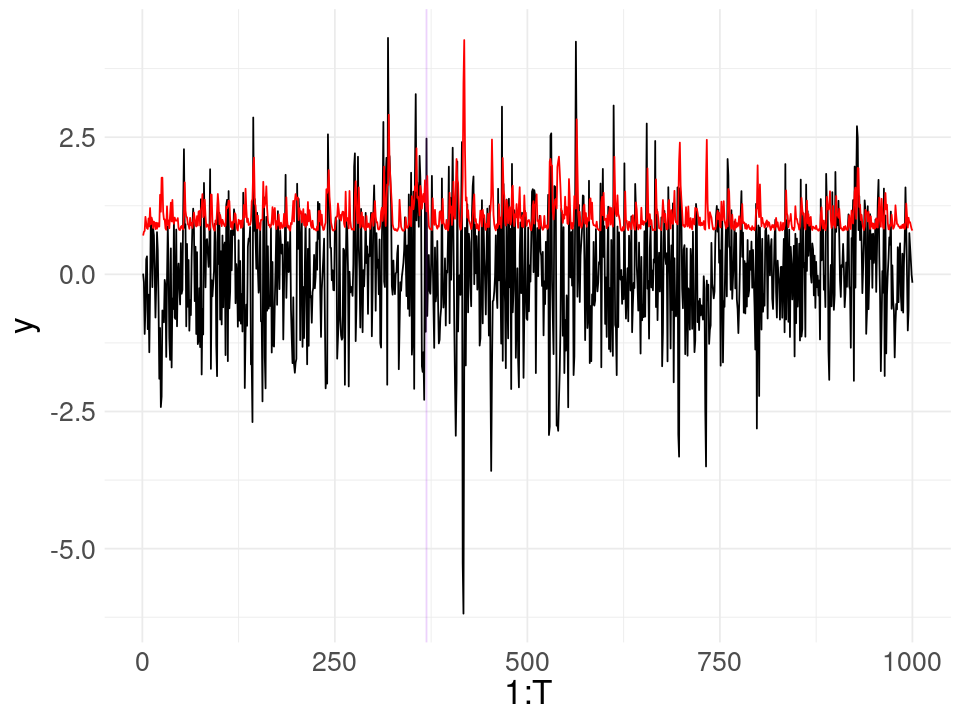

In [9]:
T <- 1000
niter <- 10000
burnin <- 5000
alpha <- c(0.5, 0.4)
beta <- c(0.2)

set.seed(10)

# -------------------------------- Sample from the GARCH model --------------------------------
yh <- sample_garch(T, alpha, beta)
y <- yh$y
h <- yh$h

# -------------------------------- Fit the Bayesian model --------------------------------
start <- Sys.time()
    fit <- fit_garch11_dirichlet(y)
elapsed_sample <- Sys.time() - start
elapsed_sample

options(repr.plot.width=8, repr.plot.height=6)
y_plot <- ggplot()+
              geom_line(aes(x = 1:T, y = y))+
              geom_line(aes(x = 1:T, y = sqrt(h)), color = "red")+
            geom_vline(aes(xintercept = 369), color = "purple", alpha = 0.2)
y_plot

In [10]:
i1 <- 355
i2 <- 360
i3 <- 400
# Multiplicative perturbations for each observation
p1 <- 3.2
p2 <- 3
p3 <- 5

#### (a) No perturbation

Time for the generation of posteriori samples: 22.82269 
Time for the divergence metrics computation: 15.59676

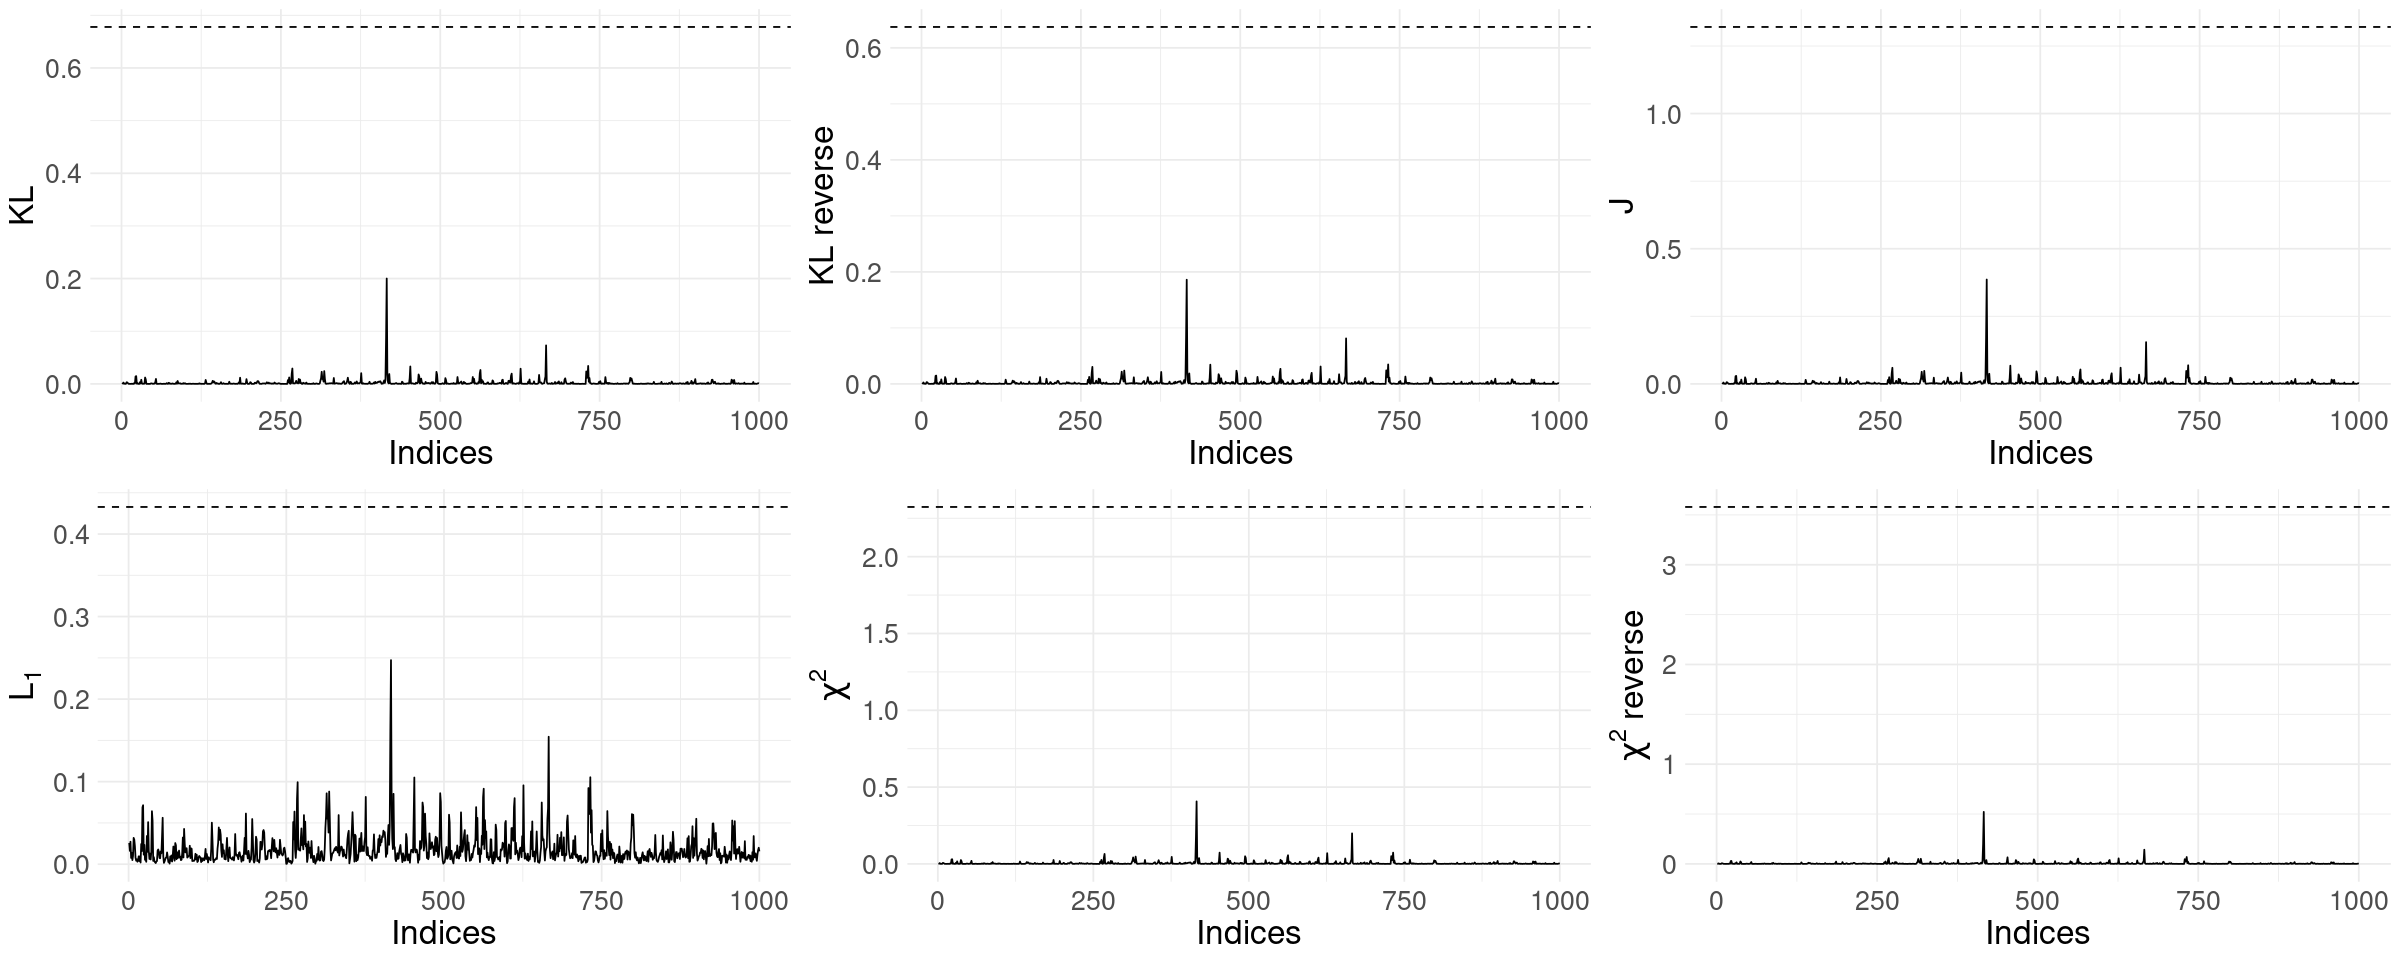

In [11]:
set.seed(1)

y_a <- y
h_a <- h

start <- Sys.time()
    fit_a <- fit_garch11_dirichlet(y_a)
elapsed_sample <- Sys.time() - start

thetas <- cbind(fit_a$alpha[,1], fit_a$alpha[,2], fit_a$beta)
hs <- fit_a$h
colnames(thetas) <- c("alpha0", "alpha1", "beta")

start <- Sys.time()
    div_a <- psi_divergences_cpp_parallel(thetas, hs, y_a, p = 1, q = 1, k_values = 1:T, verbose = FALSE)
elapsed_div <- Sys.time() - start

colnames(div_a) <- c("KL", "KL_rev", "J", "chi2", "chi2_rev", "chi2_sym", "L1", "H", "JS")
div_a <- as.data.frame(div_a)

cat("Time for the generation of posteriori samples:", elapsed_sample,"\n")
cat("Time for the divergence metrics computation:", elapsed_div)

options(repr.plot.width = 20, repr.plot.height = 8)
plot_divergences(fit_a, div_a, q = 0.95)

### (b) Observation $i_1 = 355$ perturbed

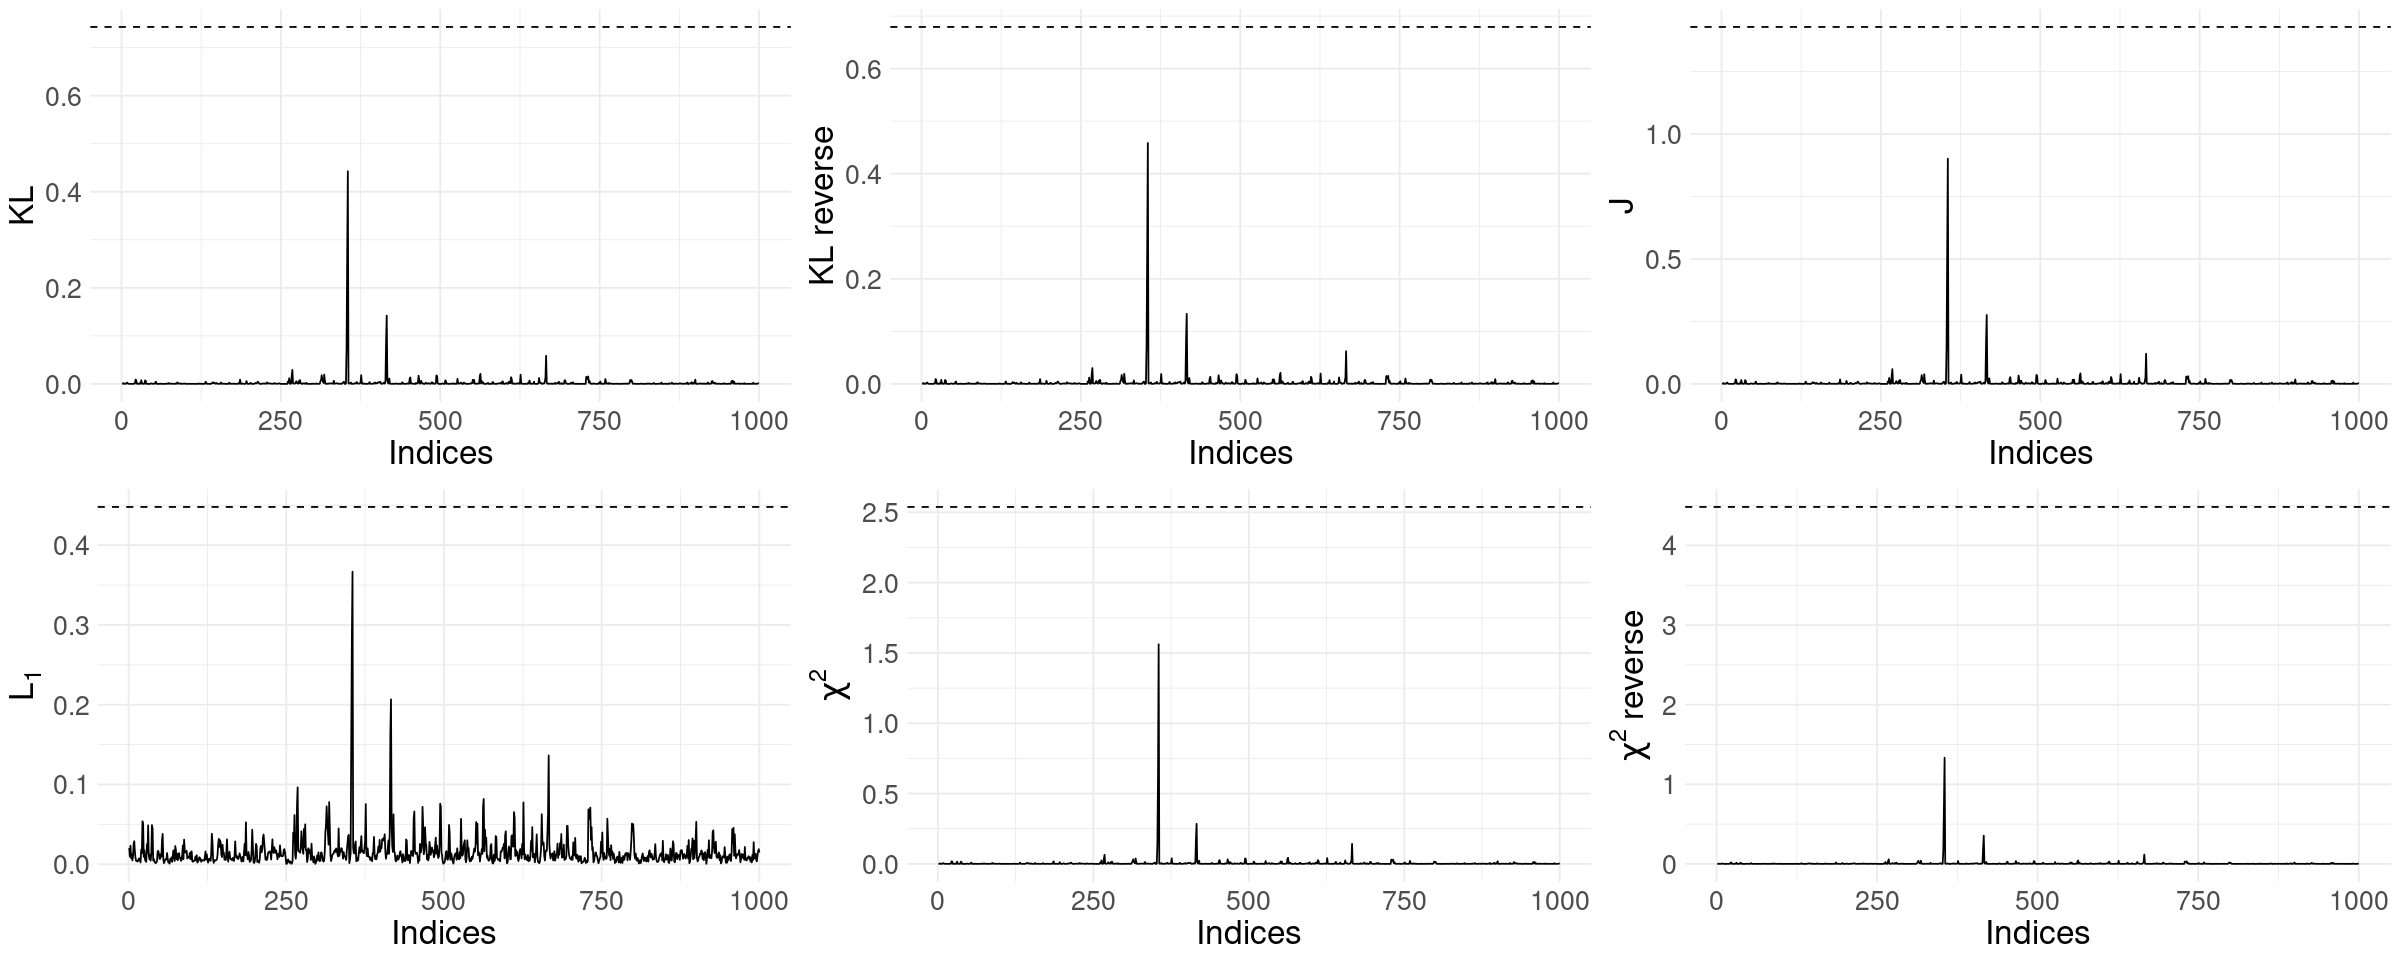

In [15]:
# i1 = 356
# i2 = 360

set.seed(2)

y_b <- y
y_b[i1] <- y_b[i1] + sign(y_b[i1]) * sqrt( h[i1] ) * p1

fit_b <- fit_garch11_dirichlet(y_b)
thetas_b <- cbind(fit_b$alpha[,1], fit_b$alpha[,2], fit_b$beta)
colnames(thetas_b) <- c("alpha0", "alpha1", "beta")
h_b <- fit_b$h

div_b <- psi_divergences_cpp_parallel(thetas_b, h_b, y_b, p = 1, q = 1, k_values = 1:T, verbose = FALSE)
colnames(div_b) <- c("KL", "KL_rev", "J", "chi2", "chi2_rev", "chi2_sym", "L1", "H", "JS")
div_b <- as.data.frame(div_b)

options(repr.plot.width = 20, repr.plot.height = 8)
plot_divergences(fit_b, div_b, q = 0.95)

### (c) Observation $i_2 = 360$ perturbed

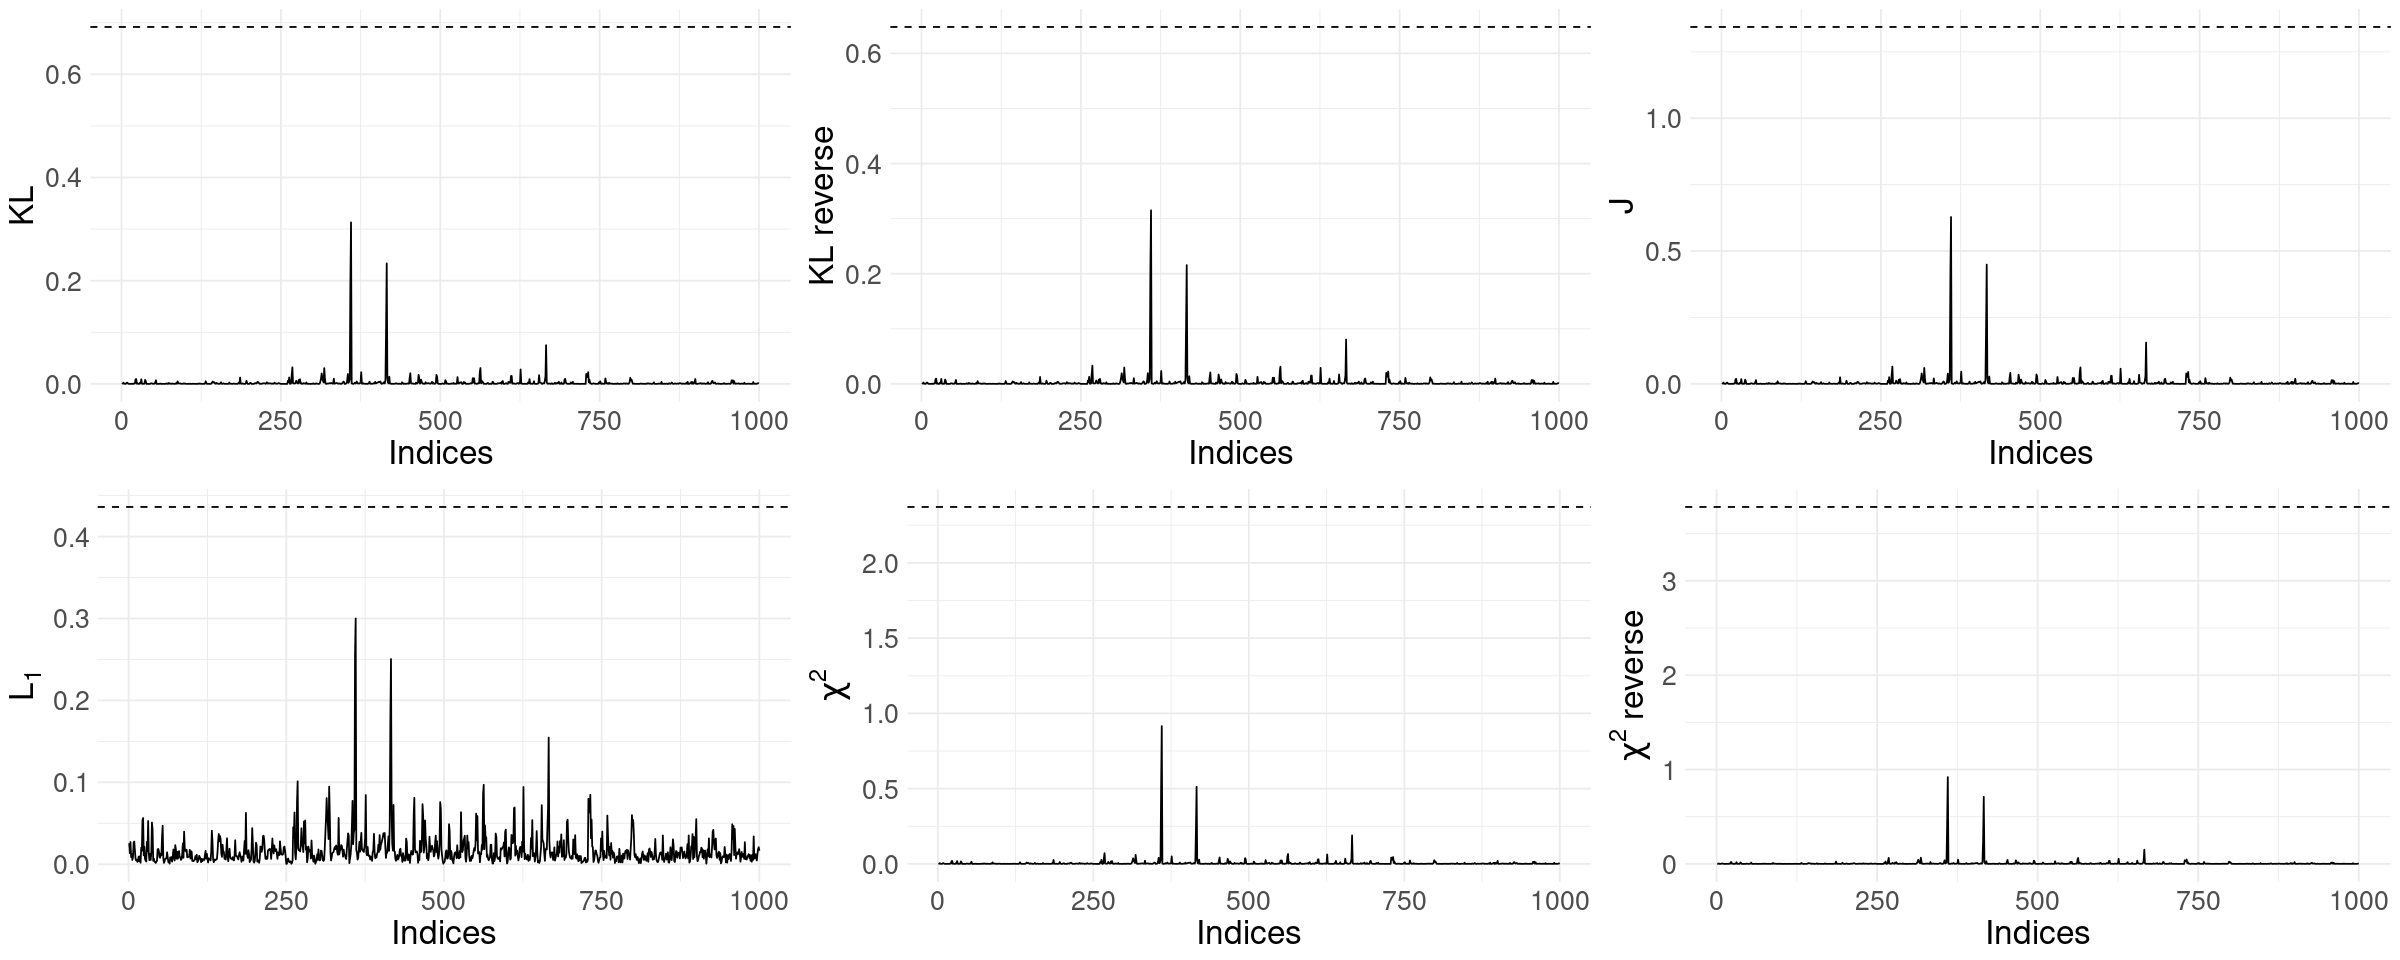

In [16]:
y_c <- y

set.seed(3)

y_c[i2] <- y_c[i2] + sign(y_c[i2]) * sqrt( h[i2] ) * p2

fit_c <- fit_garch11_dirichlet(y_c)
thetas_c <- cbind(fit_c$alpha[,1], fit_c$alpha[,2], fit_c$beta)
colnames(thetas_c) <- c("alpha0", "alpha1", "beta")
h_c <- fit_c$h

div_c <- psi_divergences_cpp_parallel(thetas_c, h_c, y_c, p = 1, q = 1, k_values = 1:T, verbose = FALSE)
colnames(div_c) <- c("KL", "KL_rev", "J", "chi2", "chi2_rev", "chi2_sym", "L1", "H", "JS")
div_c <- as.data.frame(div_c)

options(repr.plot.width = 20, repr.plot.height = 8)
plot_divergences(fit_c, div_c, q = 0.95)

### (d) Observation $i_3 = 400$ perturbed

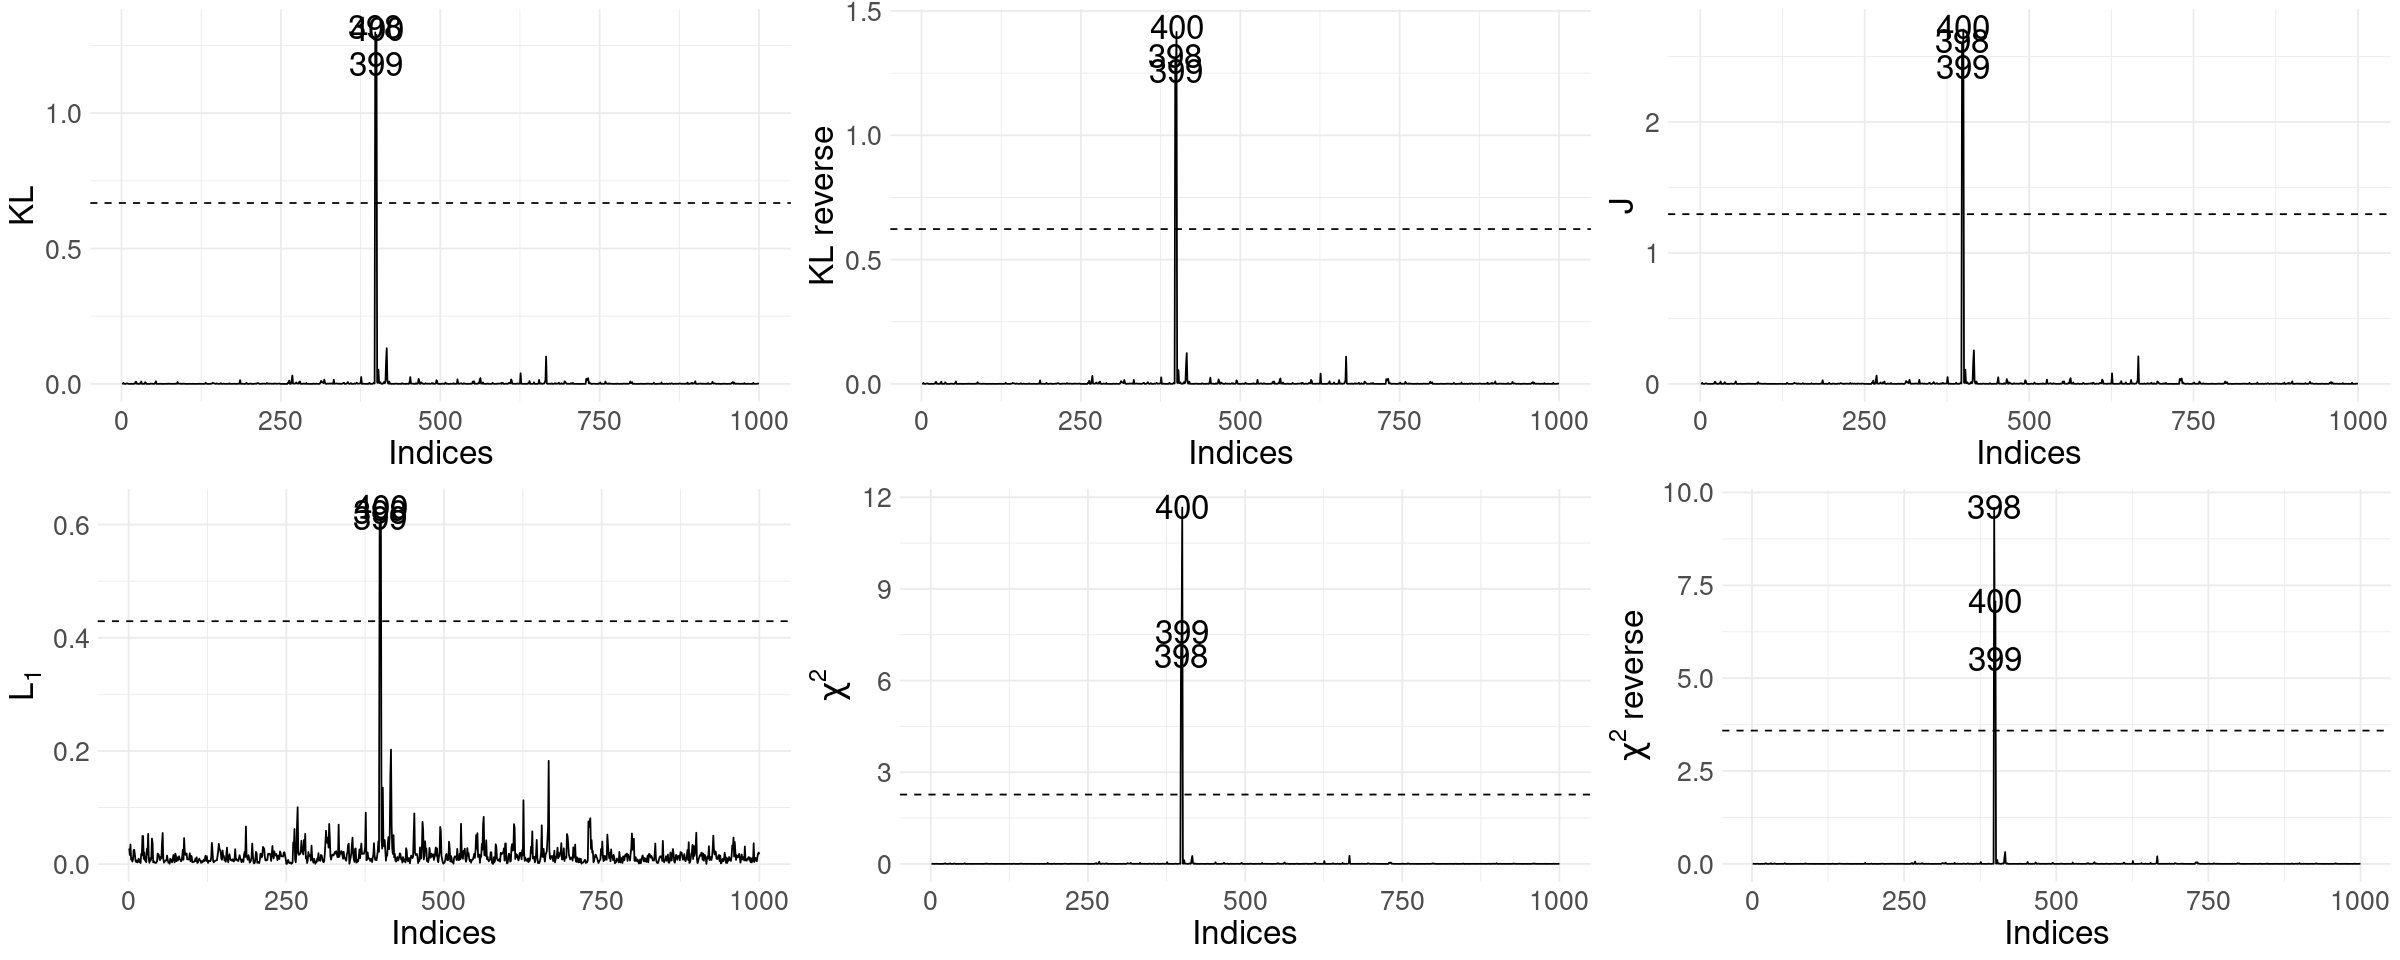

In [17]:
y_d <- y

set.seed(4)

y_d[i3] <- y_d[i3] + sign(y_d[i3]) * sqrt( h[i3] ) * p3

fit_d <- fit_garch11_dirichlet(y_d)
thetas_d <- cbind(fit_d$alpha[,1], fit_d$alpha[,2], fit_d$beta)
colnames(thetas_d) <- c("alpha0", "alpha1", "beta")
h_d <- fit_d$h

div_d <- psi_divergences_cpp_parallel(thetas_d, h_d, y_d, p = 1, q = 1, k_values = 1:T, verbose = FALSE)
colnames(div_d) <- c("KL", "KL_rev", "J", "chi2", "chi2_rev", "chi2_sym", "L1", "H", "JS")
div_d <- as.data.frame(div_d)

options(repr.plot.width = 20, repr.plot.height = 8)
plot_divergences(fit_d, div_d, q = 0.95)

### (e) Observations $i_1 = 355$ and $i_2 = 360$ perturbed

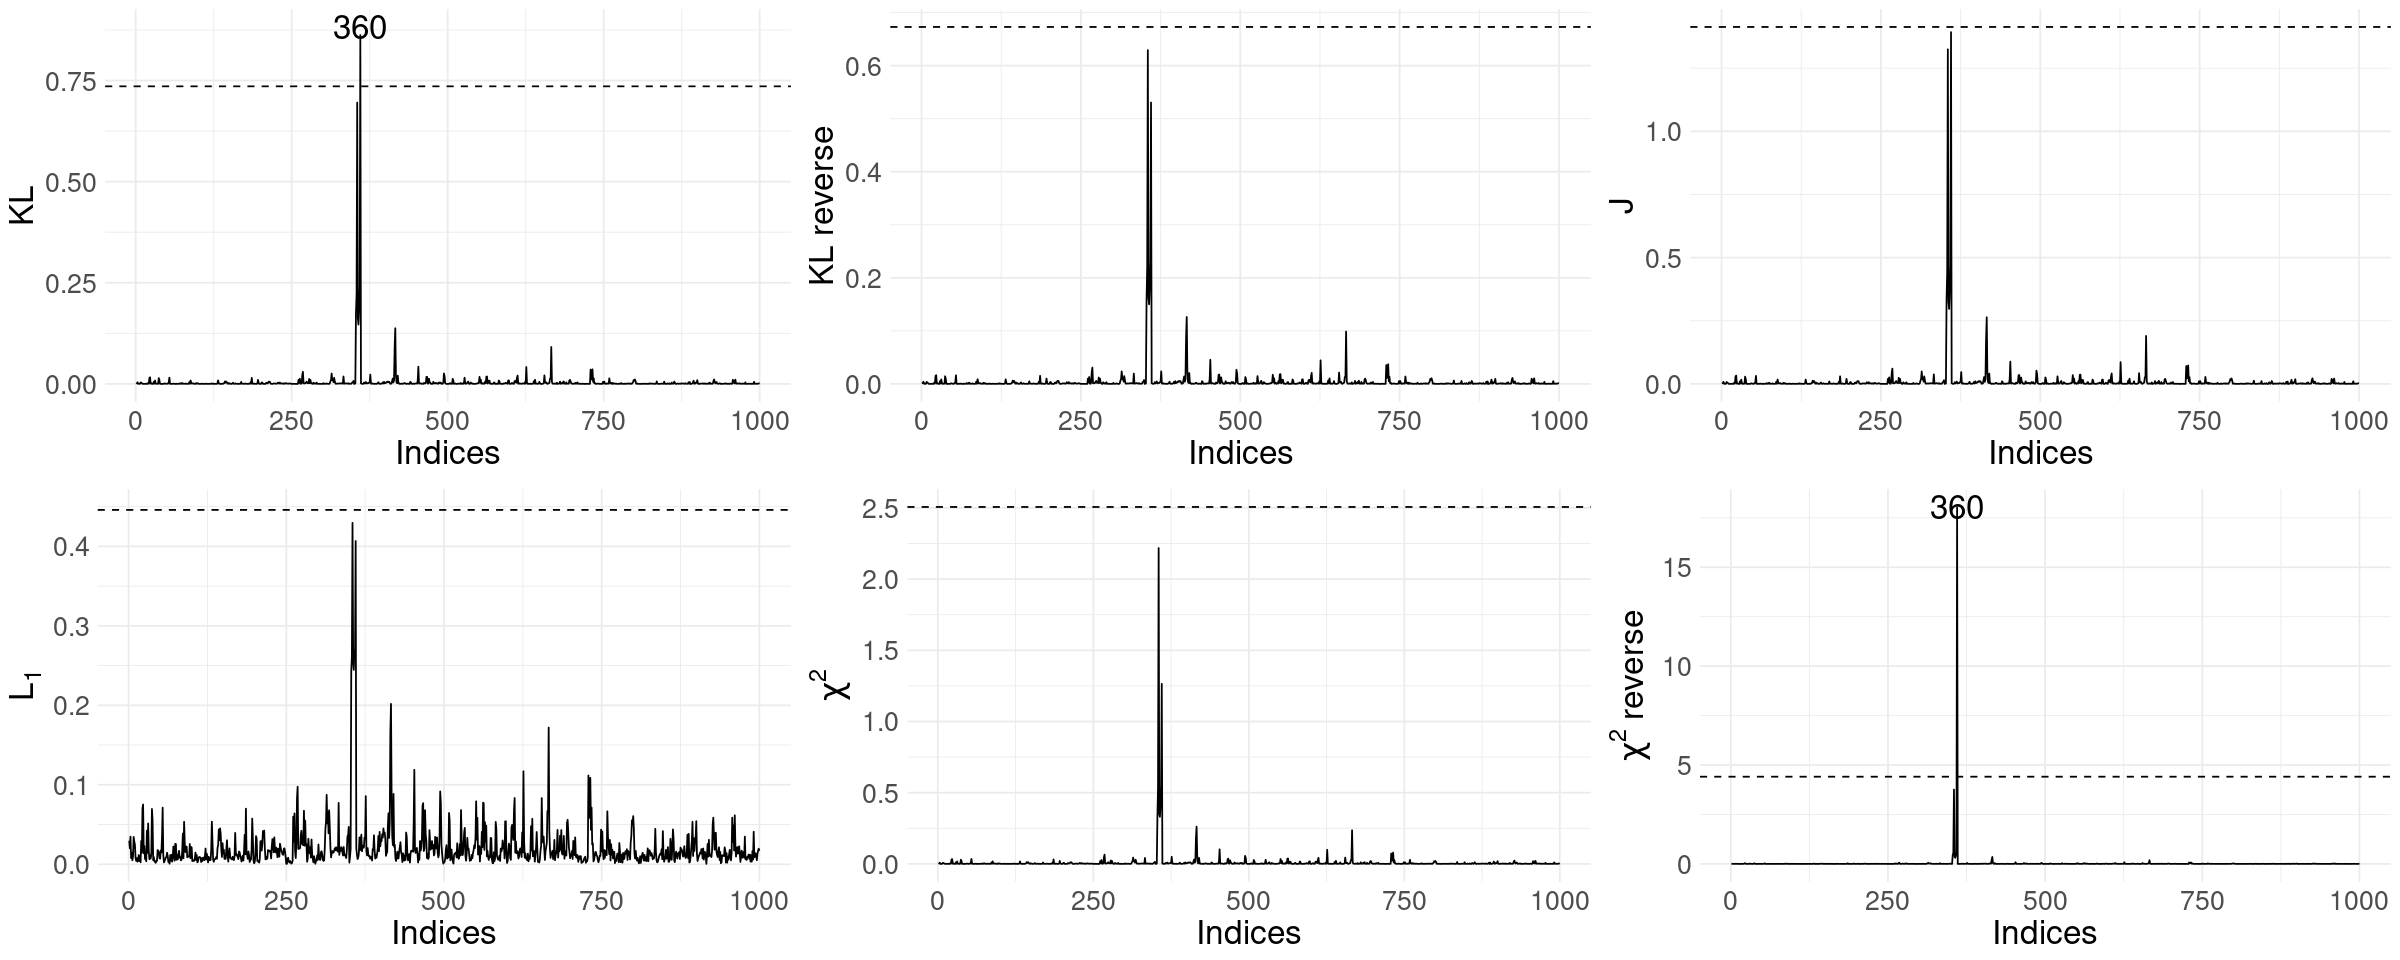

In [29]:
y_e <- y

y_e[i1] <- y_e[i1] + sign(y_e[i1]) * sqrt( h[i1] ) * p1
y_e[i2] <- y_e[i2] + sign(y_e[i2]) * sqrt( h[i2] ) * p2

fit_e <- fit_garch11_dirichlet(y_e)
thetas_e <- cbind(fit_e$alpha[,1], fit_e$alpha[,2], fit_e$beta)
colnames(thetas_e) <- c("alpha0", "alpha1", "beta")
h_e <- fit_e$h

# k_values <- sort( c( (i1-5):(i1+5), (i2-5):(i2+5) ) )

div_e <- psi_divergences_cpp_parallel(thetas_e, h_e, y_e, p = 1, q = 1, k_values = 1:T, verbose = FALSE)
# div_e <- div_e[ !duplicated(k_values), ]
# rownames(div_e) <- unique(k_values)
colnames(div_e) <- c("KL", "KL_rev", "J", "chi2", "chi2_rev", "chi2_sym", "L1", "H", "JS")
div_e <- as.data.frame(div_e)

options(repr.plot.width = 20, repr.plot.height = 8)
plot_divergences(fit_e, div_e, q = 0.95)

### (f) Observations $i_1 = 355$ and $i_3 = 400$ perturbed

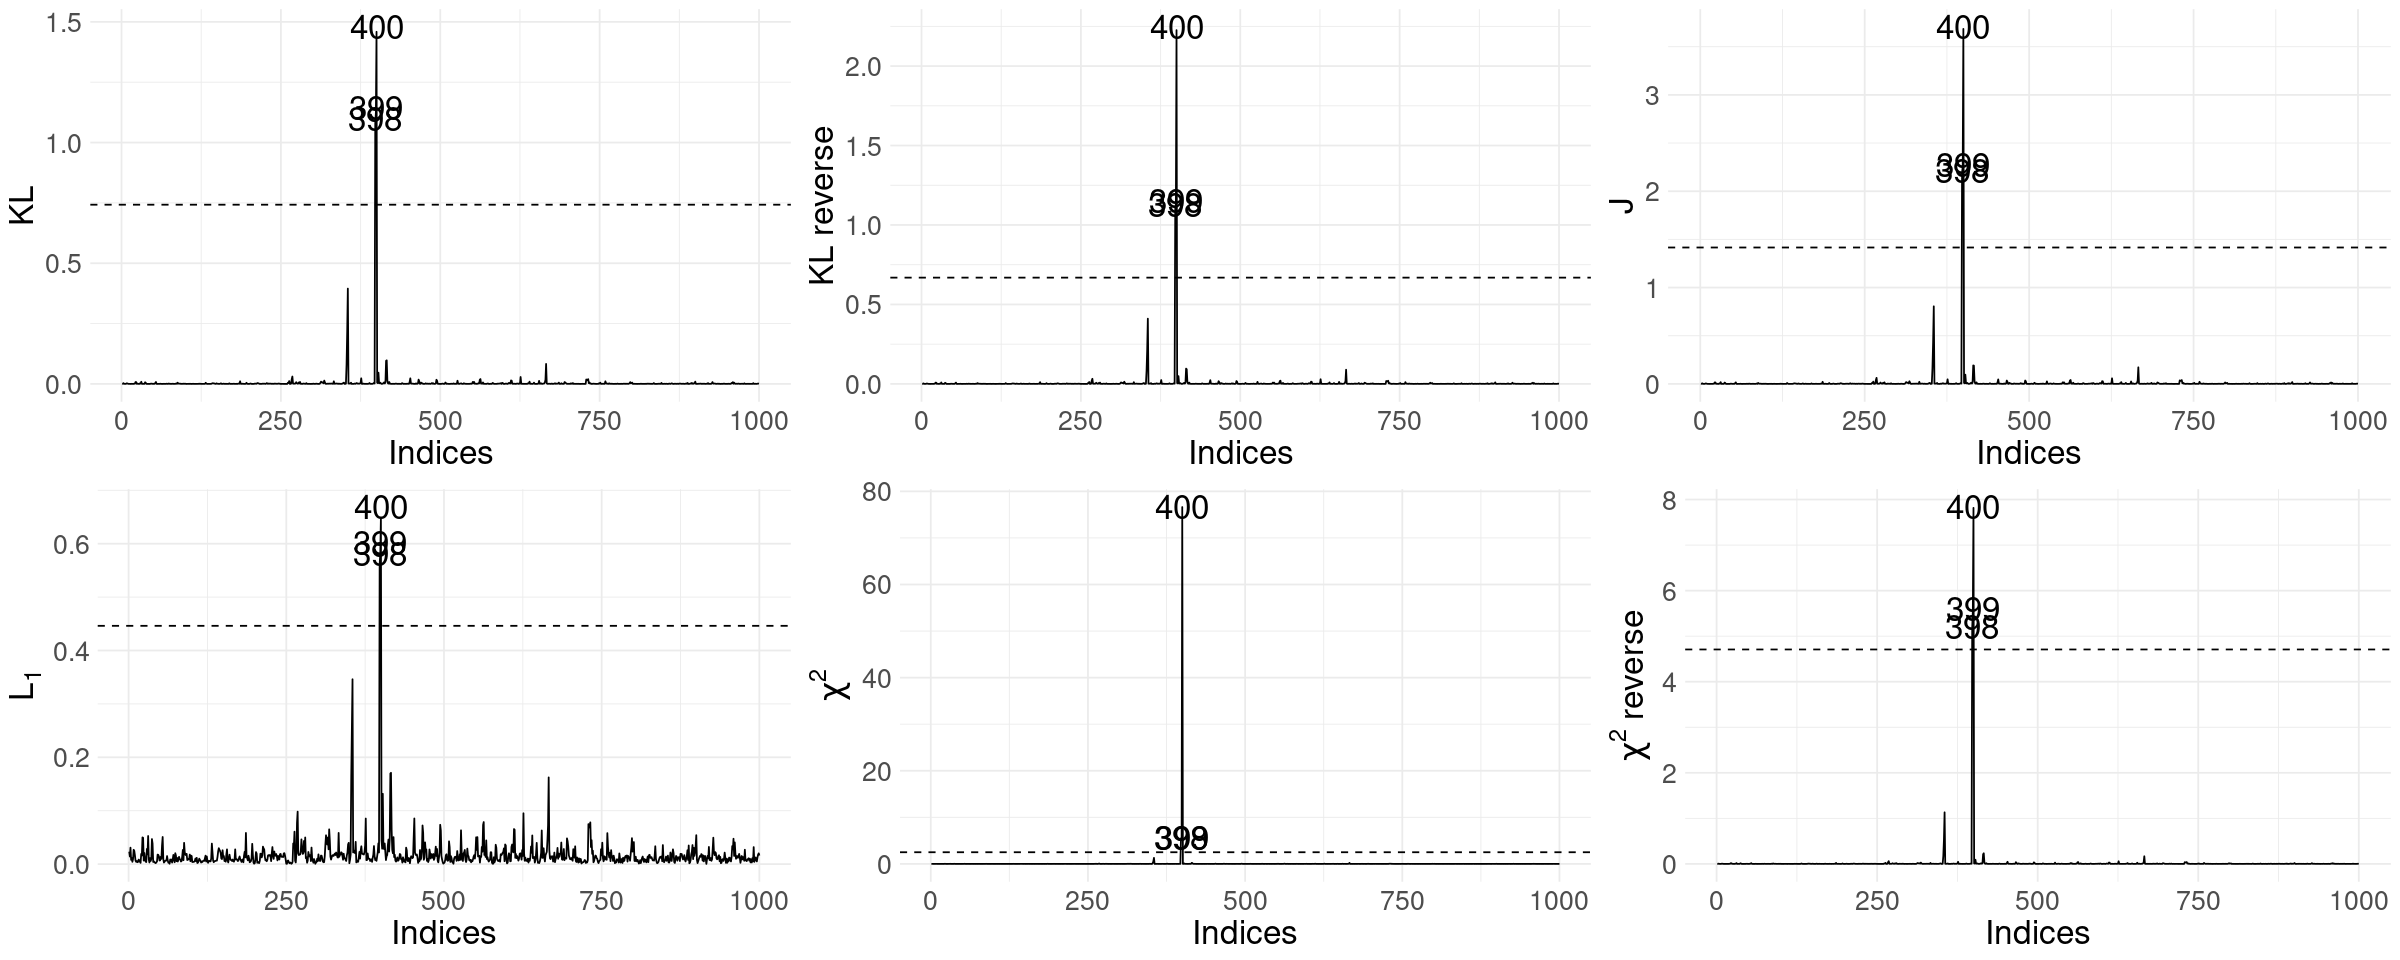

In [19]:
y_f <- y

y_f[i1] <- y_f[i1] + sign(y_f[i1]) * sqrt( h[i1] ) * p1
y_f[i3] <- y_f[i3] + sign(y_f[i3]) * sqrt( h[i3] ) * p3

fit_f <- fit_garch11_dirichlet(y_f)
thetas_f <- cbind(fit_f$alpha[,1], fit_f$alpha[,2], fit_f$beta)
colnames(thetas_f) <- c("alpha0", "alpha1", "beta")
h_f <- fit_f$h

div_f <- psi_divergences_cpp_parallel(thetas_f, h_f, y_f, p = 1, q = 1, k_values = 1:T, verbose = FALSE)
colnames(div_f) <- c("KL", "KL_rev", "J", "chi2", "chi2_rev", "chi2_sym", "L1", "H", "JS")
div_f <- as.data.frame(div_f)

options(repr.plot.width = 20, repr.plot.height = 8)
plot_divergences(fit_f, div_f, q = 0.95)

### (g) Observations $i_2 = 360$ and $i_3 = 400$ perturbed

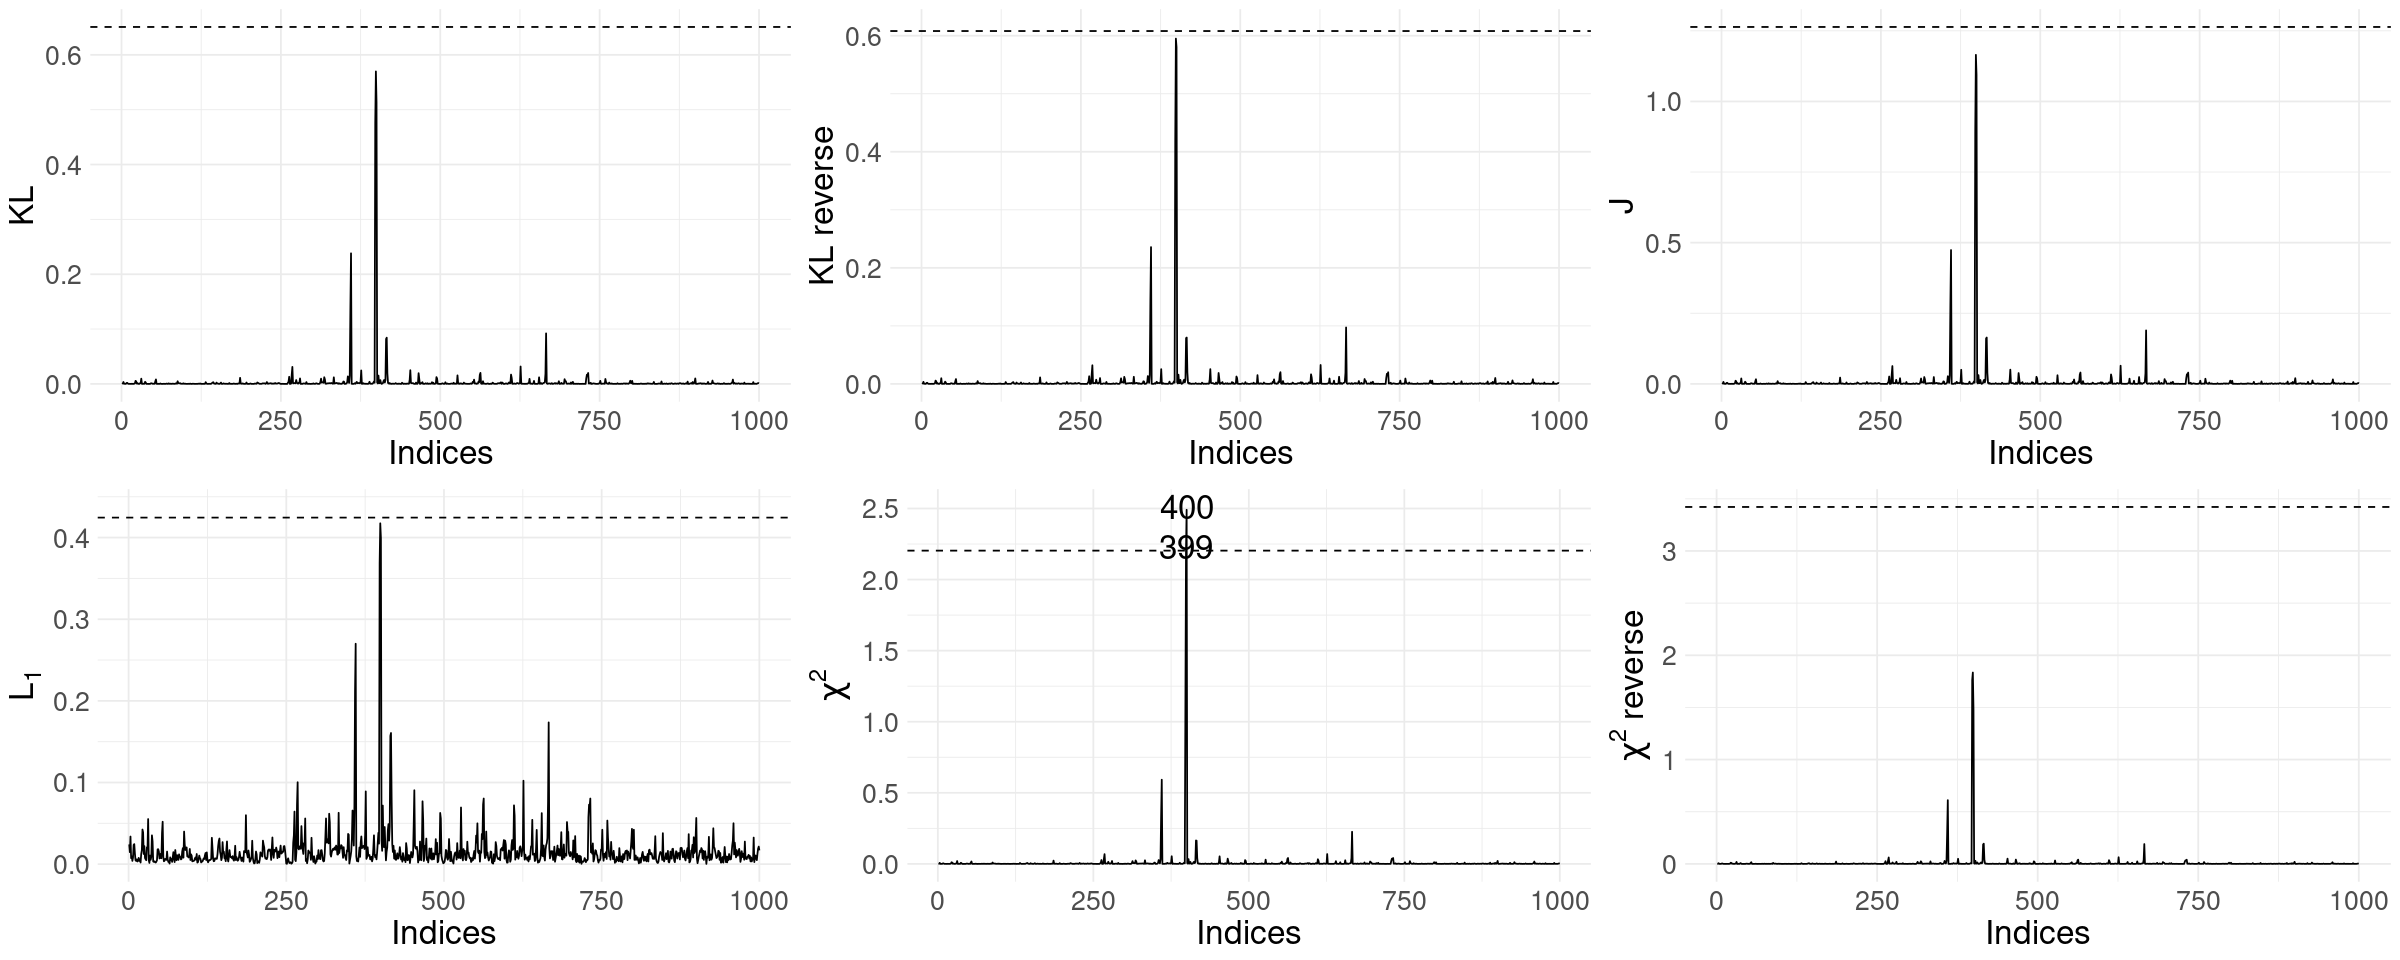

In [20]:
y_g <- y

y_g[i2] <- y_g[i2] + sign(y_g[i2]) * sqrt( h[i2] ) * p2
y_g[i3] <- y_g[i3] + sign(y_g[i3]) * sqrt( h[i3] ) * p3

fit_g <- fit_garch11_dirichlet(y_g)
thetas_g <- cbind(fit_g$alpha[,1], fit_g$alpha[,2], fit_g$beta)
colnames(thetas_g) <- c("alpha0", "alpha1", "beta")
h_g <- fit_g$h

div_g <- psi_divergences_cpp_parallel(thetas_g, h_g, y_g, p = 1, q = 1, k_values = 1:T, verbose = FALSE)
colnames(div_g) <- c("KL", "KL_rev", "J", "chi2", "chi2_rev", "chi2_sym", "L1", "H", "JS")
div_g <- as.data.frame(div_g)

options(repr.plot.width = 20, repr.plot.height = 8)
plot_divergences(fit_g, div_g, q = 0.95)

### (h) Observations $i_1 = 355$, $i_2 = 360$ and $i_3 = 400$ perturbed

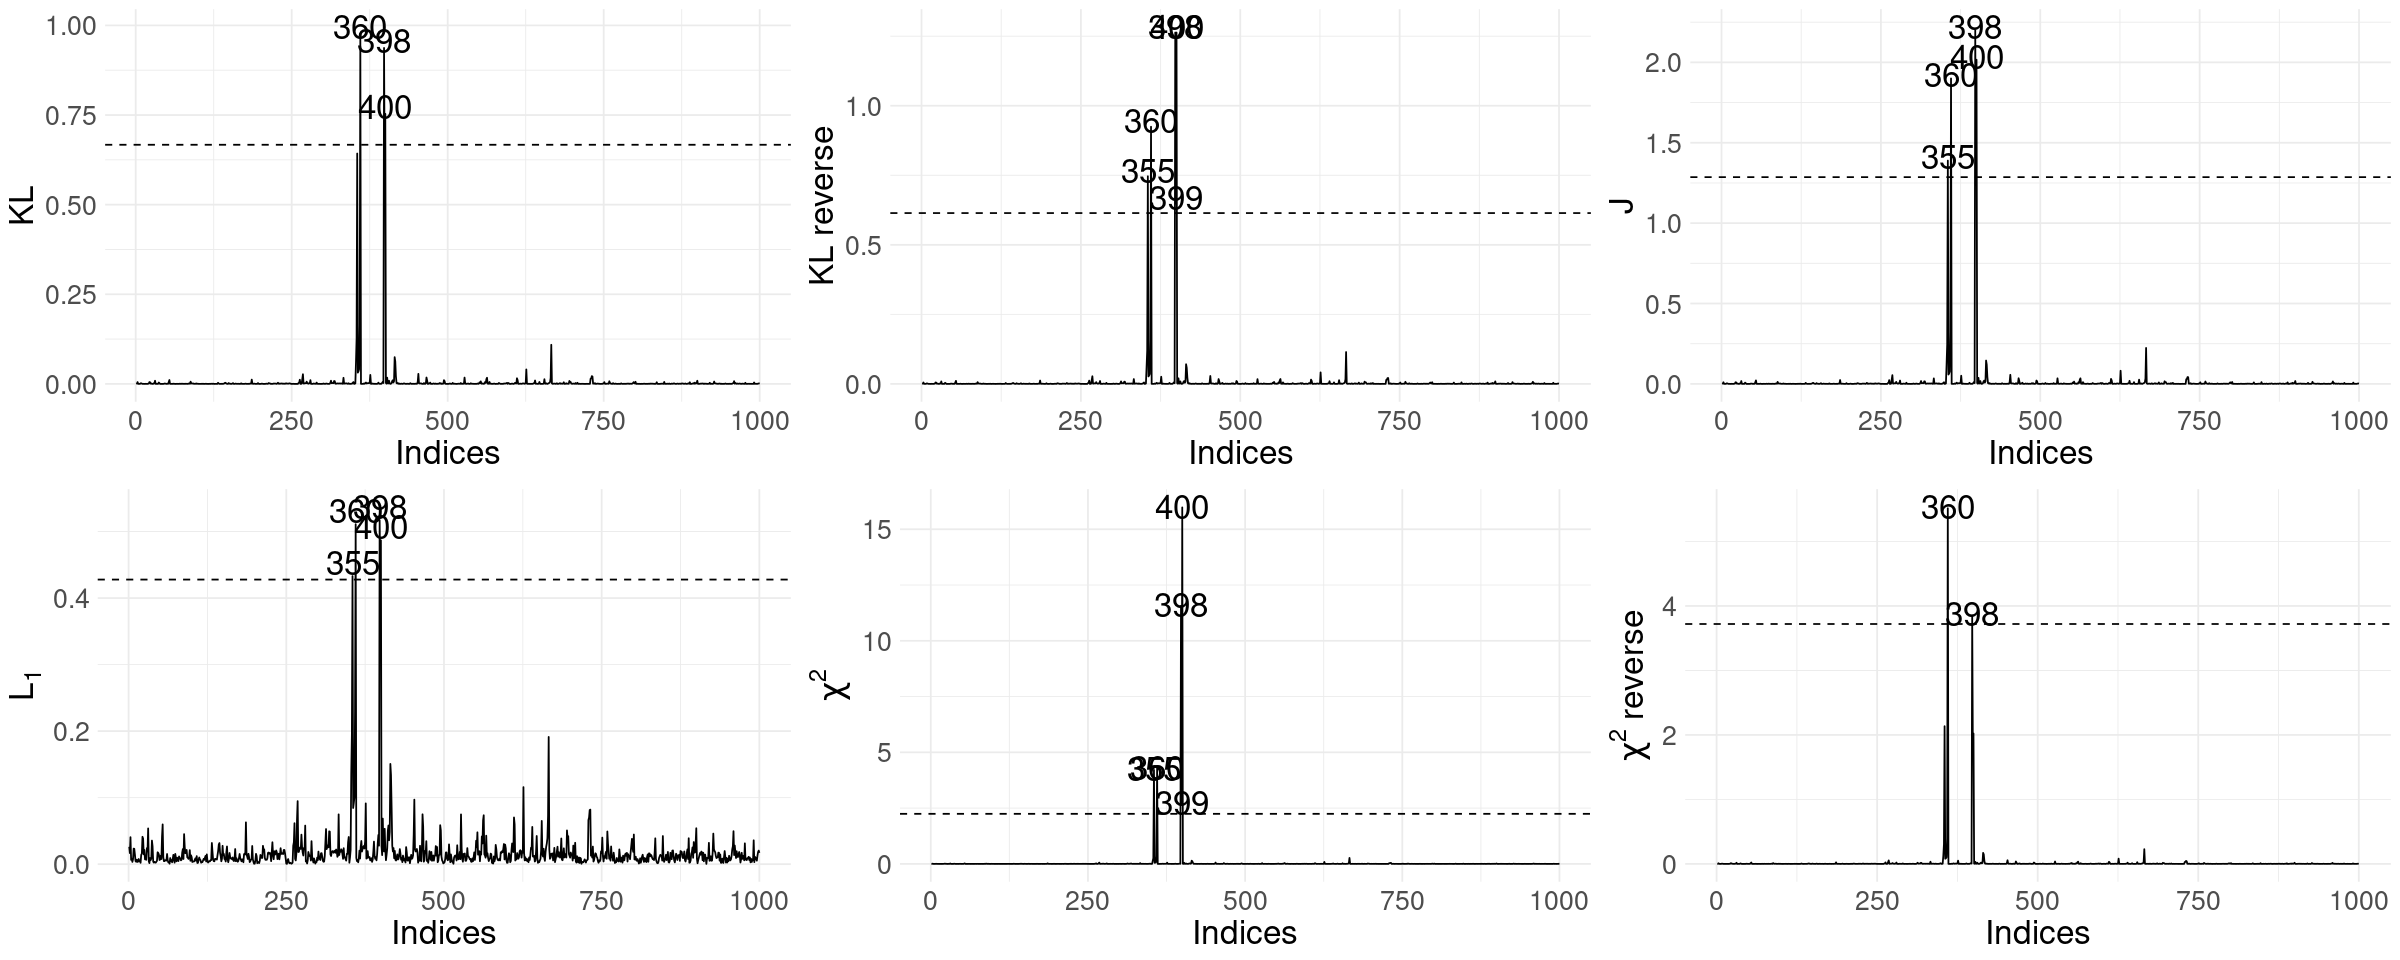

In [22]:
y_h <- y

y_h[i1] <- y_h[i1] + sign(y_h[i1]) * sqrt( h[i1] ) * p1
y_h[i2] <- y_h[i2] + sign(y_h[i2]) * sqrt( h[i2] ) * p2
y_h[i3] <- y_h[i3] + sign(y_h[i3]) * sqrt( h[i3] ) * p3

fit_h <- fit_garch11_dirichlet(y_h)
thetas_h <- cbind(fit_h$alpha[,1], fit_h$alpha[,2], fit_h$beta)
colnames(thetas_h) <- c("alpha0", "alpha1", "beta")
h_h <- fit_h$h

div_h <- psi_divergences_cpp_parallel(thetas_h, h_h, y_h, p = 1, q = 1, k_values = 1:T, verbose = FALSE)
colnames(div_h) <- c("KL", "KL_rev", "J", "chi2", "chi2_rev", "chi2_sym", "L1", "H", "JS")
div_h <- as.data.frame(div_h)

options(repr.plot.width = 20, repr.plot.height = 8)
plot_divergences(fit_h, div_h, q = 0.95)

In [48]:
divs <- round(rbind(
    div_a[c(i1, i2, i3), c(1,2,3,7,4,5)],
    div_b[c(i1, i2, i3), c(1,2,3,7,4,5)],
    div_c[c(i1, i2, i3), c(1,2,3,7,4,5)],
    div_d[c(i1, i2, i3), c(1,2,3,7,4,5)],
    div_e[c(i1, i2, i3), c(1,2,3,7,4,5)],
    div_f[c(i1, i2, i3), c(1,2,3,7,4,5)],
    div_g[c(i1, i2, i3), c(1,2,3,7,4,5)],
    div_h[c(i1, i2, i3), c(1,2,3,7,4,5)]
), 4)

divs <- cbind(rep(c(i1,i2,i3), 8), divs)
divs

,"rep(c(i1, i2, i3), 8)",KL,KL_rev,J,L1,chi2,chi2_rev
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
355,355,0.0117,0.0118,0.0236,0.0630,0.0240,0.0236
360,360,0.0033,0.0032,0.0065,0.0342,0.0064,0.0066
400,400,0.0024,0.0024,0.0048,0.0295,0.0049,0.0048
3551,355,0.4426,0.4584,0.9010,0.3666,1.5614,1.3337
3601,360,0.0027,0.0026,0.0053,0.0285,0.0052,0.0055
4001,400,0.0014,0.0014,0.0028,0.0214,0.0028,0.0028
3552,355,0.0191,0.0195,0.0386,0.0773,0.0406,0.0383
3602,360,0.3130,0.3151,0.6281,0.3000,0.9157,0.9198
4002,400,0.0016,0.0016,0.0033,0.0236,0.0033,0.0033


In [49]:
# \multirow{3}{*}{(a)} & 355 & 0.0117 & 0.0118 & 0.0236 & 0.0630 & 0.0240 & 0.0236\\
#                      & 360 & 0.0033 & 0.0032 & 0.0065 & 0.0342 & 0.0064 & 0.0066\\
#                      & 400 & 0.0024 & 0.0024 & 0.0048 & 0.0295 & 0.0049 & 0.0048\\
# \multirow{3}{*}{(b)} & 355 & 0.4426 & 0.4584 & 0.9010 & 0.3666 & 1.5614 & 1.3337\\
#                      & 360 & 0.0027 & 0.0026 & 0.0053 & 0.0285 & 0.0052 & 0.0055\\
#                      & 400 & 0.0014 & 0.0014 & 0.0028 & 0.0214 & 0.0028 & 0.0028\\
# \multirow{3}{*}{(c)} & 355 & 0.0191 & 0.0195 & 0.0386 & 0.0773 & 0.0406 & 0.0383\\
#                      & 360 & 0.3130 & 0.3151 & 0.6281 & 0.3000 & 0.9157 & 0.9198\\
#                      & 400 & 0.0016 & 0.0016 & 0.0033 & 0.0236 & 0.0033 & 0.0033\\
# \multirow{3}{*}{(d)} & 355 & 0.0067 & 0.0068 & 0.0134 & 0.0467 & 0.0138 & 0.0132\\
#                      & 360 & 0.0024 & 0.0024 & 0.0047 & 0.0277 & 0.0048 & 0.0048\\
#                      & 400 & 1.2891 & 1.4159 & 2.7049 & 0.6111 & 11.6607 & 7.0672\\
# \multirow{3}{*}{(e)} & 355 & 0.6954 & 0.6291 & 1.3245 & 0.4295 & 2.2175 & 3.7576\\
#                      & 360 & 0.8624 & 0.5304 & 1.3928 & 0.4067 & 1.2648 & 18.0281\\
#                      & 400 & 0.0025 & 0.0026 & 0.0051 & 0.0299 & 0.0052 & 0.0051\\
# \multirow{3}{*}{(f)} & 355 & 0.3948 & 0.4104 & 0.8052 & 0.3461 & 1.2898 & 1.1321\\
#                      & 360 & 0.0049 & 0.0049 & 0.0098 & 0.0416 & 0.0098 & 0.0099\\
#                      & 400 & 1.4589 & 2.2260 & 3.6849 & 0.6488 & 76.6241 & 7.8167\\
# \multirow{3}{*}{(g)} & 355 & 0.0137 & 0.0134 & 0.0271 & 0.0656 & 0.0268 & 0.0282\\
#                      & 360 & 0.2381 & 0.2357 & 0.4738 & 0.2699 & 0.5921 & 0.6109\\
#                      & 400 & 0.5132 & 0.5804 & 1.0935 & 0.3996 & 2.4906 & 1.4851\\
# \multirow{3}{*}{(h)} & 355 & 0.6426 & 0.7465 & 1.3891 & 0.4331 & 4.2120 & 2.1352\\
#                      & 360 & 0.9756 & 0.9244 & 1.9000 & 0.5110 & 4.2714 & 5.5157\\
#                      & 400 & 0.7534 & 1.2631 & 2.0165 & 0.4868 & 15.9781 & 2.0228

ERROR: Error in parse(text = input): <text>:1:2: unexpected symbol
1: \multirow
     ^
